## データ保存

In [1]:
import os
os.environ["SPEDAS_DATA_DIR"] = "/mnt/j/observation_data/"

# 電場のデータを弄ってみる

In [2]:
import pyspedas as psp
import pytplot as pt
import numpy as np
import xarray as xr
import pandas as pd

pt.del_data('*')

time_range = ['20220901/21:00:00', '20220902/00:00:00']
pt.timespan('2022-09-01/22:30:00', 1, keyword='hour')

path_base_save_plot = f'/mnt/j/KAW_observation/E_B_ratio_ERG/2022-09-01/2230-2330'

psp.erg.pwe_efd(trange=time_range, level='l2', datatype='64', coord='dsi')
psp.erg.mgf(trange=time_range, level='l2', datatype='64hz', coord='dsi')

02-Aug-25 20:50:14: del_data: No valid tplot variables found, returning
02-Aug-25 20:50:14: Downloading remote index: https://ergsc.isee.nagoya-u.ac.jp/data/ergsc/satellite/erg/pwe/efd/l2/E64Hz/2022/09/
02-Aug-25 20:50:14: File is current: /mnt/j/observation_data//ergsc/satellite/erg/pwe/efd/l2/E64Hz/2022/09/erg_pwe_efd_l2_E64Hz_dsi_20220901_v01_02.cdf


 
 
**************************************************************************
['Exploration of Energization and Radiation in Geospace (ERG) Plasma Wave Experiment (PWE) Electric Field Detector (EFD) Level 2 waveform data in DSI Coordinate System']

Information about ERG PWE EFD

PI:  ['Yoshiya Kasahara']
Affiliation:  ['Kanazawa University']

RoR of ERG project common: https://ergsc.isee.nagoya-u.ac.jp/data_info/rules_of_the_road.shtml.en
RoR of PWE/EFD: https://ergsc.isee.nagoya-u.ac.jp/mw/index.php/ErgSat/Pwe/Efd

Contact: erg_pwe_info at isee.nagoya-u.ac.jp
**************************************************************************


02-Aug-25 20:50:16: Downloading remote index: https://ergsc.isee.nagoya-u.ac.jp/data/ergsc/satellite/erg/mgf/l2/64hz/2022/09/
02-Aug-25 20:50:19: File is current: /mnt/j/observation_data//ergsc/satellite/erg/mgf/l2/64hz/2022/09/erg_mgf_l2_64hz_dsi_2022090121_v04.05.cdf
02-Aug-25 20:50:19: File is current: /mnt/j/observation_data//ergsc/satellite/erg/mgf/l2/64hz/2022/09/erg_mgf_l2_64hz_dsi_2022090122_v04.05.cdf
02-Aug-25 20:50:19: File is current: /mnt/j/observation_data//ergsc/satellite/erg/mgf/l2/64hz/2022/09/erg_mgf_l2_64hz_dsi_2022090123_v04.05.cdf


 
**************************************************************************
['Exploration of Energization and Radiation in Geospace (ERG) Magnetic Field Experiment (MGF) Level 2 64 Hz resolution magnetic field data']

Information about ERG MGF

PI:  ['Ayako Matsuoka']
Affiliation:  ['Data Analysis Center for Geomagnetism and Space Magnetism, Graduate School of Science, Kyoto University, Kitashirakawa-Oiwake Cho, Sakyo-ku Kyoto 606-8502, Japan']

RoR of ERG project common: https://ergsc.isee.nagoya-u.ac.jp/data_info/rules_of_the_road.shtml.en
RoR of MGF L2: https://ergsc.isee.nagoya-u.ac.jp/mw/index.php/ErgSat/Mgf
Contact: erg_mgf_info at isee.nagoya-u.ac.jp
**************************************************************************


['erg_mgf_l2_epoch_64hz',
 'erg_mgf_l2_date_time_64hz',
 'erg_mgf_l2_mag_64hz_dsi',
 'erg_mgf_l2_dyn_rng_64hz',
 'erg_mgf_l2_quality_64hz',
 'erg_mgf_l2_quality_64hz_gc',
 'erg_mgf_l2_spin_phase_64hz',
 'erg_mgf_l2_ti_64hz']

In [3]:
E64_data_Ex = pt.data_quants['erg_pwe_efd_l2_E64Hz_dsi_Ex_waveform']
E64_data_Ey = pt.data_quants['erg_pwe_efd_l2_E64Hz_dsi_Ey_waveform']
B64_data    = pt.data_quants['erg_mgf_l2_mag_64hz_dsi']

time_range_T = [time_range[0].replace('/', 'T'), time_range[1].replace('/', 'T')]
E64_data_Ex = E64_data_Ex.sortby('time').sel(time=slice(time_range_T[0], time_range_T[1]))
E64_data_Ey = E64_data_Ey.sortby('time').sel(time=slice(time_range_T[0], time_range_T[1]))
B64_data    = B64_data.sortby('time').sel(time=slice(time_range_T[0], time_range_T[1]))

print(E64_data_Ex)
print(E64_data_Ey)
print(B64_data)

<xarray.DataArray 'erg_pwe_efd_l2_E64Hz_dsi_Ex_waveform' (time: 676822)> Size: 3MB
array([-0.88777757, -0.8308681 , -0.78996205, ...,  0.76865107,
        0.74541116,  0.7118714 ], shape=(676822,), dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 5MB 2022-09-01T21:00:00.002088960 ... 2022...
Attributes:
    CDF:           {'VATT': {'FIELDNAM': 'Ex_waveform_64Hz', 'CATDESC': 'EFD ...
    data_att:      {'coord_sys': '', 'units': 'mV/m', 'depend_1_units': 'ms',...
    plot_options:  {'xaxis_opt': {'axis_label': '', 'crosshair': 'X', 'x_axis...
<xarray.DataArray 'erg_pwe_efd_l2_E64Hz_dsi_Ey_waveform' (time: 676822)> Size: 3MB
array([ 0.45766547,  0.453115  ,  0.43238264, ..., -0.78619236,
       -0.76076853, -0.74318665], shape=(676822,), dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 5MB 2022-09-01T21:00:00.002088960 ... 2022...
Attributes:
    CDF:           {'VATT': {'FIELDNAM': 'Ey_waveform_64Hz', 'CATDESC': 'EFD ...
    data_att:      {'coord_sys': '', '

In [4]:
import xarray as xr
import numpy as np

# --- 0. 準備：変数名は質問に合わせている -----------------------------
Ex = E64_data_Ex.sortby('time')           # 時系列を昇順に
Ey = E64_data_Ey.sortby('time')
B  = B64_data.sortby('time')              # 64 Hz 磁場ベクトル

Bx = B.isel(v_dim=0)         # dims = ('time',)
By = B.isel(v_dim=1)
Bz = B.isel(v_dim=2)

# --- 1. E を B のタイムスタンプへ線形補間 ----------------------------
Ex_i = Ex.interp(time=B.time, method='linear')
Ey_i = Ey.interp(time=B.time, method='linear')
#   • 範囲外はデフォルトで NaN。必要なら
#     .interp(..., kwargs={'fill_value': 'extrapolate'}) など

# --- 2. Ez を計算 ----------------------------------------------------
EPS = 1e-12          # ゼロ割り回避用の閾値 (単位: nT)
Ez = xr.where(np.abs(Bz) > EPS, -(Ex_i*Bx + Ey_i*By)/Bz, np.nan)
Ez.name = 'E64Hz_dsi_Ez_waveform'

# --- 3. 必要なら Dataset にまとめる --------------------------------
ds = xr.Dataset({
    'Ex_dsi': Ex_i,
    'Ey_dsi': Ey_i,
    'Ez_dsi': Ez,
    'Bx_dsi': ('time', Bx.data),
    'By_dsi': ('time', By.data),
    'Bz_dsi': ('time', Bz.data),
}, coords={'time': B.time})

ds = ds.dropna(dim='time', how='any', subset=['Ex_dsi', 'Ey_dsi', 'Bx_dsi', 'By_dsi', 'Bz_dsi'])

ds

<xarray.Dataset> Size: 38MB
Dimensions:  (time: 687369)
Coordinates:
  * time     (time) datetime64[ns] 5MB 2022-09-01T21:00:00.017222016 ... 2022...
Data variables:
    Ex_dsi   (time) float64 5MB -0.8327 -0.7913 -0.7512 ... -0.7606 -0.7325
    Ey_dsi   (time) float64 5MB 0.4533 0.4331 0.4152 ... -2.916 -2.934 -2.946
    Ez_dsi   (time) float64 5MB 6.403 6.079 5.76 ... -0.411 -0.3641 -0.3308
    Bx_dsi   (time) float64 5MB 993.4 993.3 993.3 993.4 ... 161.9 161.8 161.9
    By_dsi   (time) float64 5MB 224.4 224.5 224.6 224.7 ... -23.5 -23.54 -23.61
    Bz_dsi   (time) float64 5MB 113.3 113.3 113.4 113.4 ... -148.3 -148.3 -148.2

In [5]:
import pytplot as pt
import os
import matplotlib.pyplot as plt

# ---- xarray → tplot へ格納 ----------------------------
for var in ['Ex_dsi', 'Ey_dsi', 'Ez_dsi', 'Bx_dsi', 'By_dsi', 'Bz_dsi']:
    pt.store_data(
        var,
        data={'x': ds['time'].values, 'y': ds[var].values},
    )

pt.options(['Ex_dsi', 'Ey_dsi', 'Ez_dsi'], 'ysubtitle', '[mV/m]')
pt.options('Ex_dsi', 'ytitle', 'E_x (DSI)')
pt.options('Ey_dsi', 'ytitle', 'E_y (DSI)')
pt.options('Ez_dsi', 'ytitle', 'E_z (DSI)')
pt.options(['Bx_dsi', 'By_dsi', 'Bz_dsi'], 'ysubtitle', '[nT]')
pt.options('Bx_dsi', 'ytitle', 'B_x (DSI)')
pt.options('By_dsi', 'ytitle', 'B_y (DSI)')
pt.options('Bz_dsi', 'ytitle', 'B_z (DSI)')

# ---- プロット -----------------------------------------
# 電場 3 成分 + 磁場 3 成分を上下 2 パネルに分けて描画
vars_to_plot = ['Ex_dsi', 'Ey_dsi', 'Ez_dsi', 'Bx_dsi', 'By_dsi', 'Bz_dsi']
if os.path.isdir(path_base_save_plot):
    # フォルダが存在 → プロットを「表示せずに保存」
    fig, axes = pt.tplot(
        vars_to_plot,
        display=False,              # Jupyter 上での自動表示を抑制
        return_plot_objects=True,   # fig, axes を返してもらう
        save_png=os.path.join(path_base_save_plot, 'EB_fields_dsi.png')
    )
    plt.close(fig)
else:
    # フォルダが存在しない → プロットを通常表示
    pt.tplot(
        vars_to_plot,
        display=True   # 省略可（デフォルト）
    )

In [6]:
import xarray as xr
import numpy as np

def dsi_to_fac(ds: xr.Dataset, window_sec: float = 100.0) -> xr.Dataset:
    """DSI→FAC 変換 (64 Hz データを想定)
    Parameters
    ----------
    ds : xr.Dataset
        必須変数: Ex_dsi, Ey_dsi, Ez_dsi, Bx_dsi, By_dsi, Bz_dsi
    window_sec : float, optional
        FAC 基底を決める移動平均時間 [s]
    Returns
    -------
    ds_out : xr.Dataset
        DSI + FAC の両方を含む Dataset
    """
    # --- 0. 時系列を昇順にしておく -----------------------------------
    ds = ds.sortby('time')

    # --- 1. 平均磁場 <B> の計算 --------------------------------------
    dt = (ds.time[1] - ds.time[0]).astype('timedelta64[ns]').astype(float) * 1e-9
    win_pts = int(window_sec / dt)
    B_dsi = ds[['Bx_dsi', 'By_dsi', 'Bz_dsi']].to_array('comp')      # (comp,time)
    print(B_dsi)

    B_avg = B_dsi.rolling(time=win_pts, center=True).mean('time')          # (comp,time)
    B_avg = B_avg.transpose('time', 'comp').values                   # (N,3)

    # --- 2. FAC 基底ベクトル -----------------------------------------
    z0 = np.array([0.0, 0.0, 1.0])
    e2 = np.cross(z0, B_avg)                                              # ⟂B & ⟂z
    # z0 // B のとき e2≈0 → 代わりに x軸とクロスする等の処理を追加しても良い
    e1 = np.cross(e2, B_avg)
    e3 = B_avg

    def _normalize(v):
        return v / np.linalg.norm(v, axis=1, keepdims=True)

    e1_hat = _normalize(e1)
    e2_hat = _normalize(e2)
    e3_hat = _normalize(e3)

    # --- 3. 回転行列 R (time,3,3) とベクトル変換 ----------------------
    R = np.stack([e1_hat, e2_hat, e3_hat], axis=2)                   # columns=ê_i

    # DSI→FAC: v_fac = R · v_dsi
    E_dsi = ds[['Ex_dsi', 'Ey_dsi', 'Ez_dsi']].to_array('comp') \
              .transpose('time', 'comp').values                      # (N,3)
    B_dsi_np = B_dsi.transpose('time', 'comp').values               # (N,3)

    E_fac = np.einsum('tji,tj->ti', R, E_dsi)                        # (N,3)
    B_fac = np.einsum('tji,tj->ti', R, B_dsi_np)                     # (N,3)

    # --- 4. Dataset へ格納 ------------------------------------------
    ds_out = ds.copy()
    ds_out['Ex_fac'], ds_out['Ey_fac'], ds_out['Ez_fac'] = [
        (('time'), E_fac[:, k]) for k in range(3)]
    ds_out['Bx_fac'], ds_out['By_fac'], ds_out['Bz_fac'] = [
        (('time'), B_fac[:, k]) for k in range(3)]

    # attrs など必要ならここで設定
    return ds_out, R, e3_hat


# ---------- 使い方 -------------------------------------------------------
ds_fac, Rotation_tensor, e3_hat = dsi_to_fac(ds)

print(ds_fac[['Ex_fac', 'Ey_fac', 'Ez_fac']])
print(ds_fac[['Bx_fac', 'By_fac', 'Bz_fac']])

print(Rotation_tensor[150000, :, :])
print(e3_hat[150000, :])


<xarray.DataArray (comp: 3, time: 687369)> Size: 16MB
array([[ 993.42874964,  993.34699239,  993.32134268, ...,  161.89097203,
         161.7798872 ,  161.88571274],
       [ 224.41156303,  224.52531789,  224.59445991, ...,  -23.50283612,
         -23.53942359,  -23.61330617],
       [ 113.29699707,  113.30999756,  113.36699677, ..., -148.28199768,
        -148.25300598, -148.19400024]], shape=(3, 687369))
Coordinates:
  * time     (time) datetime64[ns] 5MB 2022-09-01T21:00:00.017222016 ... 2022...
  * comp     (comp) object 24B 'Bx_dsi' 'By_dsi' 'Bz_dsi'
<xarray.Dataset> Size: 22MB
Dimensions:  (time: 687369)
Coordinates:
  * time     (time) datetime64[ns] 5MB 2022-09-01T21:00:00.017222016 ... 2022...
Data variables:
    Ex_fac   (time) float64 5MB nan nan nan nan nan nan ... nan nan nan nan nan
    Ey_fac   (time) float64 5MB nan nan nan nan nan nan ... nan nan nan nan nan
    Ez_fac   (time) float64 5MB nan nan nan nan nan nan ... nan nan nan nan nan
<xarray.Dataset> Size: 22MB
Dime

In [7]:
import os
import numpy as np
import matplotlib.pyplot as plt


# --- 角度 θ(t) = arccos( ê₃ · ẑ_DSI ) -----------------------------
e3_z     = Rotation_tensor[:, 2, 2]                  # (N,) ← 第3列・z成分
angle_deg = np.degrees(np.arccos(e3_z))              # 0–180° に丸め
t         = ds_fac.time.values                       # or ds.time.values

# フォルダが存在するか
if os.path.isdir(path_base_save_plot):
    # ── 存在する → プロットを作って保存のみ、Notebook上には表示しない
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(t, angle_deg, lw=1)
    ax.set_ylabel(r'∠($\bf{B}_{0}$, $\bf{\hat{z}}$(DSI))  [deg]')
    ax.set_xlabel('Time')
    ax.set_title(r'Rotation angle between $\bf{B}_{0}$ and ERG spin axis')
    ax.grid(True)
    plt.tight_layout()

    # ファイル名は適宜変更
    save_path = os.path.join(path_base_save_plot, 'rotation_angle.png')
    fig.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.close(fig)

else:
    # ── 存在しない → 通常どおり表示だけ
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(t, angle_deg, lw=1)
    ax.set_ylabel(r'∠($\bf{B}_{0}$, $\bf{\hat{z}}$(DSI))  [deg]')
    ax.set_xlabel('Time')
    ax.set_title(r'Rotation angle between $\bf{B}_{0}$ and ERG spin axis')
    ax.grid(True)
    plt.tight_layout()
    plt.show()


In [8]:
import os
import pytplot as pt
import numpy as np

# --- 1. pytplot 変数への格納 はそのまま ----
epoch = ds_fac.time.values.astype('datetime64[ns]').astype('int64') * 1e-9

for comp in ['x', 'y', 'z']:
    pt.store_data(f'E_fac_{comp}', data={'x': epoch, 'y': ds_fac[f'E{comp}_fac'].values})
    pt.store_data(f'B_fac_{comp}', data={'x': epoch, 'y': ds_fac[f'B{comp}_fac'].values})

    pt.options(f'E_fac_{comp}', 'ytitle', f'E_{comp} (FAC)\n[mV/m]')
    pt.options(f'B_fac_{comp}', 'ytitle', f'B_{comp} (FAC)\n[nT]')

for comp in ['perp', 'para']:
    if comp == 'perp':
        ds_E = np.sqrt(ds_fac['Ex_fac'].values**2 + ds_fac['Ey_fac'].values**2)
        ds_B = np.sqrt(ds_fac['Bx_fac'].values**2 + ds_fac['By_fac'].values**2)
    else:  # 'para'
        ds_E = ds_fac['Ez_fac'].values
        ds_B = ds_fac['Bz_fac'].values

    pt.store_data(f'E_fac_{comp}', data={'x': epoch, 'y': ds_E})
    pt.store_data(f'B_fac_{comp}', data={'x': epoch, 'y': ds_B})

    pt.options(f'E_fac_{comp}', 'ytitle', f'E_{comp} (FAC)\n[mV/m]')
    pt.options(f'B_fac_{comp}', 'ytitle', f'B_{comp} (FAC)\n[nT]')

# ------------------------------------------------------------
# 2. フォルダ存在チェック付きで tplot 発行
# ------------------------------------------------------------
vars_to_plot = [
    'E_fac_x', 'E_fac_y', 'E_fac_z',
    'B_fac_x', 'B_fac_y', 'B_fac_z'
]

if os.path.isdir(path_base_save_plot):
    # フォルダがある → 表示せずに保存のみ
    fig, axes = pt.tplot(
        vars_to_plot,
        display=False,              # Jupyter 上の自動表示を抑制
        return_plot_objects=True,   # fig, axes を返してもらう
        save_png=os.path.join(path_base_save_plot, 'EB_fields_fac.png')
    )
    # 完全に表示を防ぐために閉じる
    import matplotlib.pyplot as plt
    plt.close(fig)

else:
    # フォルダがない → 通常の表示のみ
    pt.tplot(
        vars_to_plot,
        display=True   # デフォルトなので省略可
    )


In [9]:
import os
import numpy as np
from scipy.signal import butter, sosfiltfilt
import pytplot as pt
import matplotlib.pyplot as plt


# ---------- 1. Butterworth ハイパス設定 -----------------------
fs     = 64.0              # サンプリング周波数 [Hz]
cutoff = 1/6               # 0.25 Hz (spin 周期 8 s より少し高め)
sos    = butter(N=4, Wn=cutoff / (fs/2),
                btype='high', output='sos')

def highpass_segmented(y, sos):
    """
    欠損(NaN) が混じる配列を NaN 区間で分割しつつ filtfilt する関数
    """
    good = np.isfinite(y)
    out  = np.full_like(y, np.nan)
    idx  = np.where(good)[0]
    segs = np.split(idx, np.where(np.diff(idx) != 1)[0] + 1)
    padlen = 3 * (sos.shape[0] - 1)
    for s in segs:
        if len(s) <= padlen:
            continue
        out[s] = sosfiltfilt(sos, y[s])
    return out

# ---------- 2. B_fac_* にフィルタを掛けて新変数を登録 ---------------
epoch = ds_fac.time.values.astype('datetime64[ns]').astype('int64') * 1e-9

for comp in ['x', 'y', 'z']:
    for EB in ['E', 'B']:
        var_in  = f'{EB}_fac_{comp}'
        da      = pt.data_quants[var_in]
        hp_data = highpass_segmented(da.data, sos)
        var_out = f'{var_in}_hp'
        pt.store_data(var_out,
                      data={'x': da.time.values, 'y': hp_data})
        pt.options(var_out, 'ytitle',        f'{EB}_{comp} (HP)\n[nT]' if EB=='B' else f'{EB}_{comp} (HP)\n[mV/m]')

# ---------- 3. プロット（フォルダある→保存のみ／ない→表示） ----
vars_hp = [
    'E_fac_x_hp', 'E_fac_y_hp', 'E_fac_z_hp',
    'B_fac_x_hp', 'B_fac_y_hp', 'B_fac_z_hp'
]

if os.path.isdir(path_base_save_plot):
    # 存在する → 表示せずに保存のみ
    fig, axes = pt.tplot(
        vars_hp,
        display=False,
        return_plot_objects=True,
        save_png=os.path.join(path_base_save_plot, 'EB_fields_fac_hp.png')
    )
    plt.close(fig)
else:
    # 存在しない → 通常表示
    pt.tplot(
        vars_hp,
        display=True
    )


In [10]:
E_x_hp = pt.data_quants['E_fac_x_hp']
B_x_hp = pt.data_quants['B_fac_x_hp']

print(E_x_hp)
print(B_x_hp)

<xarray.DataArray 'E_fac_x_hp' (time: 687369)> Size: 5MB
array([nan, nan, nan, ..., nan, nan, nan], shape=(687369,))
Coordinates:
  * time     (time) datetime64[ns] 5MB 2022-09-01T21:00:00.017222144 ... 2022...
Attributes:
    plot_options:  {'xaxis_opt': {'axis_label': '', 'crosshair': 'X', 'x_axis...
<xarray.DataArray 'B_fac_x_hp' (time: 687369)> Size: 5MB
array([nan, nan, nan, ..., nan, nan, nan], shape=(687369,))
Coordinates:
  * time     (time) datetime64[ns] 5MB 2022-09-01T21:00:00.017222144 ... 2022...
Attributes:
    plot_options:  {'xaxis_opt': {'axis_label': '', 'crosshair': 'X', 'x_axis...


In [11]:
import os
import sys
import importlib
import numpy as np
import matplotlib.pyplot as plt
import pyspedas as psp
import pytplot as pt

sys.path.append("..")
import module_handmade.tdwavelet as tw
importlib.reload(tw)

# 存在チェック用にフォルダを作らない派ならコメントアウトしてOK
# os.makedirs(path_base_save_plot, exist_ok=True)

# 1. 各成分に対して CWT 計算とオプション設定
for EB, unit in [('B', 'nT^2/Hz'), ('E', '(mV/m)^2/Hz')]:
    for comp in ['x', 'y', 'z']:
        var_in = f'{EB}_fac_{comp}_hp'
        if var_in not in pt.data_quants:
            print(f'skip (no {var_in})')
            continue

        tw.tdwavelet(
            var_in,
            dt=1/64,
            scales=range(1, 256),
            suffix='_cwt',
            zrange=[1e-6, 1e2]
        )

        var_out = f'{var_in}_cwt'
        # 軸設定
        pt.options(var_out, 'ylog', 1)
        pt.options(var_out, 'ztitle', 'PSD')
        pt.options(var_out, 'zsubtitle', unit)
        pt.options(var_out, 'ytitle', f'{EB}_{comp} (FAC)')
        pt.options(var_out, 'ysubtitle', '[Hz]')
        pt.options(var_out, 'colormap', 'turbo')
        pt.options(var_out, 'zrange', [1e-6, 1e2])

# 2. タイムスパンを変えつつプロット／保存
#time_windows = [
#    np.datetime64('2022-09-01T22:30') + np.timedelta64(5, 'm')*n
#    for n in range(12)
#]
#
#for t0 in time_windows:
#    start_str = str(t0)             # "2022-09-01T22:30:00" など
#    # tplot のタイムスパン設定
#    pt.timespan(start_str, 5, keyword='minute')
#    print(f"plotting window: {start_str}")
#
#    vars_cwt = [
#        'E_fac_x_hp_cwt', 'E_fac_y_hp_cwt', 'E_fac_z_hp_cwt',
#        'B_fac_x_hp_cwt', 'B_fac_y_hp_cwt', 'B_fac_z_hp_cwt'
#    ]
#
#    if os.path.isdir(path_base_save_plot):
#        # フォルダがあれば保存のみ
#        # ファイル名に時刻を埋め込む（コロンがあるとダメなので置換）
#        fn_time = start_str.replace(':', '').replace('T', '_')
#        save_png = os.path.join(path_base_save_plot,
#                                f'EB_fields_fac_cwt_{fn_time}.png')
#
#        fig, axes = pt.tplot(
#            vars_cwt,
#            display=False,
#            return_plot_objects=True,
#            save_png=save_png
#        )
#        plt.close(fig)
#
#    else:
#        # フォルダがなければ表示のみ
#        pt.tplot(
#            vars_cwt,
#            display=True
#        )


In [12]:
print(pt.data_quants['E_fac_x_hp_cwt'])
print(pt.data_quants['E_fac_y_hp_cwt'])
print(pt.data_quants['E_fac_z_hp_cwt'])
print(pt.data_quants['B_fac_x_hp_cwt'])
print(pt.data_quants['B_fac_y_hp_cwt'])
print(pt.data_quants['B_fac_z_hp_cwt'])

<xarray.DataArray 'E_fac_x_hp_cwt' (time: 683147, v_dim: 255)> Size: 1GB
array([[3.22320908e-06,            nan,            nan, ...,
                   nan,            nan,            nan],
       [5.69173734e-07,            nan,            nan, ...,
                   nan,            nan,            nan],
       [1.48352113e-08,            nan,            nan, ...,
                   nan,            nan,            nan],
       ...,
       [1.43907588e-07,            nan,            nan, ...,
                   nan,            nan,            nan],
       [2.83910633e-07,            nan,            nan, ...,
                   nan,            nan,            nan],
       [7.62638499e-06,            nan,            nan, ...,
                   nan,            nan,            nan]],
      shape=(683147, 255))
Coordinates:
  * time       (time) datetime64[ns] 5MB 2022-09-01T21:01:10.054502144 ... 20...
    spec_bins  (v_dim) float64 2kB 64.0 32.0 21.33 16.0 ... 0.253 0.252 0.251
    v  

In [13]:
e = pt.data_quants['E_fac_x_hp_cwt'].values
b = pt.data_quants['B_fac_x_hp_cwt'].values
print(np.sum(~np.isfinite(e)), np.sum(~np.isfinite(b)))


5908544 5908544


## 各成分のNoise(Median)を抽出

In [14]:
import os
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import pytplot as pt


# --- 1. PSD 変数リストと時間範囲 -----------------------------
vars_psd = [
    'E_fac_x_hp_cwt', 'E_fac_y_hp_cwt', 'E_fac_z_hp_cwt',
    'B_fac_x_hp_cwt', 'B_fac_y_hp_cwt', 'B_fac_z_hp_cwt'
]
t0, t1 = '2022-09-01T21:30:00', '2022-09-01T22:00:00'

# --- 2. 各変数ごとに median を計算して Dataset にまとめる ----
noise_da_dict = {}
for v in vars_psd:
    if v not in pt.data_quants:
        print(f'skip (no {v})')
        continue

    dq_cut = pt.data_quants[v].sel(time=slice(t0, t1))
    freq   = dq_cut.spec_bins.values
    med    = np.nanmedian(dq_cut.data, axis=0)

    med_da = xr.DataArray(
        data   = med,
        dims   = ['frequency'],
        coords = {'frequency': freq},
        name   = v
    )
    noise_da_dict[v] = med_da

noise_ds = xr.Dataset(noise_da_dict)
print(noise_ds)

# --- 3. プロット or 保存 --------------------------------------
fig, ax = plt.subplots(figsize=(6,4))
for key in noise_ds.data_vars:
    label = key.split('_')[0] + '_' + key.split('_')[2]
    ax.loglog(noise_ds['frequency'], noise_ds[key], label=label)

ax.set_xlabel('Frequency [Hz]')
ax.set_ylabel('Median PSD')
ax.set_title(r'Noise floor 21:30-22:00 (median) (E: (mV/m)$^2$/Hz, B: (nT)$^2$/Hz)')
ax.grid(True, which='both', ls=':')
ax.legend()
plt.tight_layout()

if os.path.isdir(path_base_save_plot):
    # フォルダが存在 → 保存のみ
    # ファイル名にコロンが入るとまずいので除去
    fn = f"noise_median_{t0.replace(':','')}_{t1.replace(':','')}.png"
    save_path = os.path.join(path_base_save_plot, fn)
    fig.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.close(fig)
    print(f"saved to {save_path}")
else:
    # フォルダが存在しない → 通常表示
    plt.show()



<xarray.Dataset> Size: 14kB
Dimensions:         (frequency: 255)
Coordinates:
  * frequency       (frequency) float64 2kB 64.0 32.0 21.33 ... 0.252 0.251
Data variables:
    E_fac_x_hp_cwt  (frequency) float64 2kB 2.961e-06 3.192e-07 ... 8.577 8.624
    E_fac_y_hp_cwt  (frequency) float64 2kB 1.048e-07 2.523e-08 ... 0.4467
    E_fac_z_hp_cwt  (frequency) float64 2kB 1.068e-10 1.67e-09 ... 5.562e-07
    B_fac_x_hp_cwt  (frequency) float64 2kB 1.689e-07 2.742e-06 ... 0.0005136
    B_fac_y_hp_cwt  (frequency) float64 2kB 2.815e-07 3.766e-06 ... 0.001103
    B_fac_z_hp_cwt  (frequency) float64 2kB 2.64e-07 3.345e-06 ... 0.0009191
saved to /mnt/j/KAW_observation/E_B_ratio_ERG/2022-09-01/2230-2330/noise_median_2022-09-01T213000_2022-09-01T220000.png


In [15]:
import os
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import pytplot as pt

# ------------------------------------------------------------
# 2. clean_vars を pytplot に登録
# ------------------------------------------------------------
vars_psd    = [
    'E_fac_x_hp_cwt', 'E_fac_y_hp_cwt', 'E_fac_z_hp_cwt',
    'B_fac_x_hp_cwt', 'B_fac_y_hp_cwt', 'B_fac_z_hp_cwt'
]
frequency   = noise_ds['frequency'].values  # shape=(Nf,)
clean_vars  = []

for v in vars_psd:
    if v not in pt.data_quants:
        print(f'skip (no {v})')
        continue

    # 元の PSD (time x freq)
    dq        = pt.data_quants[v]
    noise_vec = noise_ds[v].values           # shape=(Nf,)
    cleaned   = dq.data - noise_vec[None, :]
    cleaned[cleaned <= 0] = np.nan           # log 表示できない小数値は NaN に

    # 新変数名
    v_out = v.replace('_cwt', '_clean')
    pt.store_data(
        v_out,
        data={'x': dq.time.values, 'y': cleaned, 'v': frequency}
    )

    # 軸タイトル・凡例・スケール設定
    # 例：ytitle_list に対応する順序でラベルを設定
    ytitle_list     = [
        'E_x (FAC)', 'E_y (FAC)', 'E_z (FAC)',
        'B_x (FAC)', 'B_y (FAC)', 'B_z (FAC)'
    ]
    zsubtitle_list  = [
        '(mV/m)^2/Hz', '(mV/m)^2/Hz', '(mV/m)^2/Hz',
        '(nT)^2/Hz',    '(nT)^2/Hz',    '(nT)^2/Hz'
    ]
    idx = vars_psd.index(v)

    pt.options(v_out, 'ytitle',      ytitle_list[idx])
    pt.options(v_out, 'ysubtitle',   '[Hz]')
    pt.options(v_out, 'ztitle',      'PSD (S–N)')
    pt.options(v_out, 'zsubtitle',   zsubtitle_list[idx])
    pt.options(v_out, 'colormap',    'turbo')
    pt.options(v_out, 'ylog',        1)        # 周波数軸 log
    pt.options(v_out, 'spec',        1)        # スペクトログラムモード
    pt.options(v_out, 'zlog',        1)        # カラー軸 log
    pt.options(v_out, 'zrange',      [1e-6, 1e2])

    clean_vars.append(v_out)

# ------------------------------------------------------------
# 3. タイムウィンドウを変えつつ保存 or 表示
# ------------------------------------------------------------
#time_windows = [
#    np.datetime64('2022-09-01T23:05') + np.timedelta64(5, 'm') * n
#    for n in range(5)
#]
#
#for t0 in time_windows:
#    ts = str(t0)  # '2022-09-01T22:30:00'
#    pt.timespan(ts, 5, keyword='minute')
#    print(f"Window: {ts}")
#
#    if os.path.isdir(path_base_save_plot):
#        # フォルダがある → 保存のみ
#        fn_time = ts.replace(':', '').replace('T', '_')
#        save_png = os.path.join(
#            path_base_save_plot,
#            f'EB_fields_fac_cwt_clean_{fn_time}.png'
#        )
#
#        # display=False で plt.show() を抑制、return_plot_objects=True で fig, axes を取得
#        fig, axes = pt.tplot(
#            clean_vars,
#            display=False,             # tplot の出力そのままキャプチャ
#            return_plot_objects=True,
#            save_png=save_png
#        )
#        # 図を閉じて Notebook 上への自動表示も抑制
#        plt.close(fig)
#        print(f"Saved: {save_png}")
#
#    else:
#        # フォルダがない → Notebook 上に表示のみ
#        pt.tplot(
#            clean_vars,
#            display=True
#        )


import pyspedas as psp
import pytplot as pt

psp.erg.pwe_hfa(trange=time_range, level='l3')

import pytplot as pt
pt.tplot(['erg_pwe_hfa_l3_1min_ne_mgf'])

import pytplot as pt
number_density_l3 = pt.data_quants['erg_pwe_hfa_l3_1min_ne_mgf']
Bx_time = pt.data_quants['B_fac_x_hp_dpwrspc'].time
number_density_l3_i = number_density_l3.interp(time=Bx_time, method='linear')
pt.store_data('erg_pwe_hfa_l3_1min_ne_mgf_interp', data={'x': Bx_time.values, 'y': number_density_l3_i}, attr_dict=number_density_l3.attrs)
pt.tplot(['erg_pwe_hfa_l3_1min_ne_mgf_interp'])

In [16]:
import os
import numpy as np
import pytplot as pt
import xarray as xr
import matplotlib.pyplot as plt

path_base_save_plot = f'/mnt/j/KAW_observation/E_B_ratio_ERG/2022-09-01/2230-2330'

# --- 1. B_total を計算し、ローリング平均用の win_pts を定義 ---
Bx = pt.data_quants['B_fac_x'].sel(time=slice(*time_range_T))
By = pt.data_quants['B_fac_y'].sel(time=slice(*time_range_T))
Bz = pt.data_quants['B_fac_z'].sel(time=slice(*time_range_T))

# numpy 配列ではなく xarray.DataArray のまま計算
B_total = np.sqrt(Bx.data**2 + By.data**2 + Bz.data**2) * 1e-9  # nT→T

# 各サンプル間隔を秒で取得
dt = (Bx.time.values[1] - Bx.time.values[0]).astype('timedelta64[ns]').astype(float) * 1e-9

# 例：100秒を移動平均したいなら
win_secs = 100.0
win_pts = int(win_secs / dt)

# xarray.DataArray に戻してローリング平均
B_total_da = xr.DataArray(
    data=B_total,
    coords={'time': Bx.time.values},
    dims=['time']
)
B_total_roll = B_total_da.rolling(time=win_pts, center=True).mean()

# --- 2. pytplot 変数に登録 ----------------------------------
pt.store_data(
    'B_total_T',
    data={
        'x': B_total_roll.time.values,
        'y': B_total_roll.values
    }
)
pt.options('B_total_T', 'ytitle', 'B (total)')
pt.options('B_total_T', 'ysubtitle', '[T]')

# --- 3. プロット or 保存 ----------------------------------
pt.timespan('2022-09-01/22:30:00', 1, keyword='hour')

if os.path.isdir(path_base_save_plot):
    save_path = os.path.join(path_base_save_plot, 'B_total_rolling.png')
    fig, axes = pt.tplot(
        'B_total_T',
        display=False,
        return_plot_objects=True,
        save_png=save_path
    )
    plt.close(fig)
    print(f"Saved plot to {save_path}")
else:
    pt.tplot('B_total_T', display=True)



Saved plot to /mnt/j/KAW_observation/E_B_ratio_ERG/2022-09-01/2230-2330/B_total_rolling.png


density = number_density_l3_i.sel(time=slice(*time_range_T))
density_time = density.time.values

dt_ns = np.median(np.diff(density_time).astype('timedelta64[ns]').astype(float))
dt_sec = dt_ns * 1e-9          # 例: ≈ 4 s とか

B_total_avg = pt.data_quants['B_total_T-avg']
B_total_match = B_total_avg.interp(time=density_time)  # xarray の .interp

mu0 = 4*np.pi*1e-7
mp  = 1.6726219e-27
n_i = density.values * 1e6           # cm⁻³ → m⁻³

v_A = B_total_match.values / np.sqrt(mu0 * mp * n_i)

psp.avg_data('B_total_T', res=dt_sec)                 # → 'B_total_T-avg'
pt.store_data('Alfven_speed',
              data={'x': density_time, 'y': v_A})
pt.options('Alfven_speed', 'ytitle', 'Alfvén speed')
pt.options('Alfven_speed', 'ysubtitle', '[m/s]')
pt.tplot('Alfven_speed')

print(pt.data_quants['Alfven_speed'].time)

# 軌道データから、衛星速度(DSI)を導出

In [17]:
import os
import pyspedas as psp
import pytplot as pt
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

path_base_save_plot = f'/mnt/j/KAW_observation/E_B_ratio_ERG/2022-09-01/2230-2330'
# ──────────────────────────
# 1. 軌道＆磁場ロード＋GSE速度計算
# ──────────────────────────
psp.erg.orb(trange=time_range, level='l2', datatype='def')
psp.erg.mgf(trange=time_range, level='l2', datatype='64hz', coord='gse')

pos   = pt.data_quants['erg_orb_l2_pos_gse'].data   # (Nt,3)[R_E]
t_pos = pt.data_quants['erg_orb_l2_pos_gse'].time.values

R_E_m = 6.378137e6
t_s   = t_pos.astype('datetime64[ns]').astype(float) * 1e-9
v_gse = np.gradient(pos * R_E_m, t_s, axis=0)

v_sc_gse = xr.DataArray(
    data=v_gse, dims=('time','v_dim'),
    coords={'time': t_pos},
    attrs={'units':'m/s','desc':'$V_{sc}$ (GSE)'}
)

pt.store_data('v_sc_gse', data={'x': t_s, 'y': v_gse})
pt.options('v_sc_gse', 'ytitle', r'$V_{sc}$ (GSE) [m/s]')
pt.options('v_sc_gse', 'legend_names', ['x','y','z'])

# ──────────────────────────
# 2. GSE→J2000→DSI 変換
# ──────────────────────────
# (1) GSE→J2000
psp.cotrans(
    name_in   = 'v_sc_gse',
    name_out  = 'v_sc_j2000',
    coord_in  = 'gse',
    coord_out = 'j2000'
)
pt.options('v_sc_j2000', 'ytitle', r'$V_{sc}$ (J2000) [m/s]')
pt.options('v_sc_j2000', 'legend_names', ['x','y','z'])

# (2) J2000→DSI
from pyspedas.projects.erg.satellite.erg.common.cotrans.dsi2j2000 import dsi2j2000

dsi2j2000(name_in='v_sc_j2000', name_out='v_sc_dsi', J20002DSI=True)
pt.options('v_sc_dsi', 'ytitle', r'$V_{sc}$ (DSI) [m/s]')
pt.options('v_sc_dsi', 'legend_names', ['x','y','z'])

# ──────────────────────────
# 3. 各プロットを「保存のみ／表示のみ」で切り替え
# ──────────────────────────
pt.timespan('2022-09-01/22:30:00', 1, keyword='hour')

for var in ['v_sc_gse','v_sc_j2000','v_sc_dsi']:
    if os.path.isdir(path_base_save_plot):
        png_path = os.path.join(path_base_save_plot, f'{var}.png')
        pt.tplot(var, save_png=png_path, display=False)
        plt.close('all')
        print(f"Saved: {png_path}")
    else:
        pt.tplot(var, display=True)


02-Aug-25 20:52:23: Downloading remote index: https://ergsc.isee.nagoya-u.ac.jp/data/ergsc/satellite/erg/orb/def/2022/
02-Aug-25 20:52:23: File is current: /mnt/j/observation_data//ergsc/satellite/erg/orb/def/2022/erg_orb_l2_20220901_v05.cdf
02-Aug-25 20:52:23: Downloading remote index: https://ergsc.isee.nagoya-u.ac.jp/data/ergsc/satellite/erg/mgf/l2/64hz/2022/09/


 
**************************************************************************
['Exploration of Energization and Radiation in Geospace (ERG) Level-2 orbit data']

Information about ERG orbit


RoR of ERG project common: https://ergsc.isee.nagoya-u.ac.jp/data_info/rules_of_the_road.shtml.en

Contact: erg-sc-core at isee.nagoya-u.ac.jp
**************************************************************************


02-Aug-25 20:52:26: File is current: /mnt/j/observation_data//ergsc/satellite/erg/mgf/l2/64hz/2022/09/erg_mgf_l2_64hz_gse_2022090121_v04.05.cdf
02-Aug-25 20:52:26: File is current: /mnt/j/observation_data//ergsc/satellite/erg/mgf/l2/64hz/2022/09/erg_mgf_l2_64hz_gse_2022090122_v04.05.cdf
02-Aug-25 20:52:26: File is current: /mnt/j/observation_data//ergsc/satellite/erg/mgf/l2/64hz/2022/09/erg_mgf_l2_64hz_gse_2022090123_v04.05.cdf
02-Aug-25 20:52:27: ['gse', 'gei', 'j2000']
02-Aug-25 20:52:27: Running transformation: subgse2gei
02-Aug-25 20:52:27: Running transformation: subgei2j2000
02-Aug-25 20:52:27: Setting coordinate system for v_sc_j2000
02-Aug-25 20:52:27: Output variable: v_sc_j2000
02-Aug-25 20:52:27: wildcard_expand: No match found for erg_att_sprate
02-Aug-25 20:52:27: Downloading remote index: https://ergsc.isee.nagoya-u.ac.jp/data/ergsc/satellite/erg/att/txt/


 
**************************************************************************
['Exploration of Energization and Radiation in Geospace (ERG) Magnetic Field Experiment (MGF) Level 2 64 Hz resolution magnetic field data']

Information about ERG MGF

PI:  ['Ayako Matsuoka']
Affiliation:  ['Data Analysis Center for Geomagnetism and Space Magnetism, Graduate School of Science, Kyoto University, Kitashirakawa-Oiwake Cho, Sakyo-ku Kyoto 606-8502, Japan']

RoR of ERG project common: https://ergsc.isee.nagoya-u.ac.jp/data_info/rules_of_the_road.shtml.en
RoR of MGF L2: https://ergsc.isee.nagoya-u.ac.jp/mw/index.php/ErgSat/Mgf
Contact: erg_mgf_info at isee.nagoya-u.ac.jp
**************************************************************************


02-Aug-25 20:52:28: File is current: /mnt/j/observation_data//ergsc/satellite/erg/att/txt/erg_att_l2_20220831_v03.txt
02-Aug-25 20:52:28: File is current: /mnt/j/observation_data//ergsc/satellite/erg/att/txt/erg_att_l2_20220901_v03.txt
02-Aug-25 20:52:28: File is current: /mnt/j/observation_data//ergsc/satellite/erg/att/txt/erg_att_l2_20220902_v03.txt
02-Aug-25 20:52:29: Downloading remote index: https://ergsc.isee.nagoya-u.ac.jp/data/ergsc/satellite/erg/orb/def/2022/
02-Aug-25 20:52:29: File is current: /mnt/j/observation_data//ergsc/satellite/erg/orb/def/2022/erg_orb_l2_20220831_v05.cdf
02-Aug-25 20:52:29: File is current: /mnt/j/observation_data//ergsc/satellite/erg/orb/def/2022/erg_orb_l2_20220901_v05.cdf
02-Aug-25 20:52:29: File is current: /mnt/j/observation_data//ergsc/satellite/erg/orb/def/2022/erg_orb_l2_20220902_v05.cdf
02-Aug-25 20:52:29: tinterpol (linear) was applied to: erg_orb_l2_pos_gse-itrp
02-Aug-25 20:52:29: ['gse', 'gei', 'j2000']
02-Aug-25 20:52:29: Running transfo

 
**************************************************************************
['Exploration of Energization and Radiation in Geospace (ERG) Level-2 orbit data']

Information about ERG orbit


RoR of ERG project common: https://ergsc.isee.nagoya-u.ac.jp/data_info/rules_of_the_road.shtml.en

Contact: erg-sc-core at isee.nagoya-u.ac.jp
**************************************************************************
J2000 --> DSI
Saved: /mnt/j/KAW_observation/E_B_ratio_ERG/2022-09-01/2230-2330/v_sc_gse.png
Saved: /mnt/j/KAW_observation/E_B_ratio_ERG/2022-09-01/2230-2330/v_sc_j2000.png
Saved: /mnt/j/KAW_observation/E_B_ratio_ERG/2022-09-01/2230-2330/v_sc_dsi.png


In [18]:
V_sc_dsi = pt.data_quants['v_sc_dsi']

V_sc_dsi = V_sc_dsi.interp(time=pt.data_quants['B_fac_x_hp'].time, method='linear')

V_sc_fac_np = np.einsum('tji,tj->ti', Rotation_tensor, V_sc_dsi.values)  # (N,3) × (N,3,3) → (N,3)

V_sc_fac_perp_np = np.sqrt(V_sc_fac_np[:, 0]**2 + V_sc_fac_np[:, 1]**2)  # (N,)

pt.store_data('v_sc_fac',
              data={'x': V_sc_dsi.time.values, 'y': V_sc_fac_np},
              attr_dict=V_sc_dsi.attrs)

pt.store_data('v_sc_fac_perp',
              data={'x': V_sc_dsi.time.values, 'y': V_sc_fac_perp_np})

pt.options('v_sc_fac', 'char_size', 15)
pt.options('v_sc_fac', 'ytitle', r'$V_{\mathrm{sc}}$ (FAC)')
pt.options('v_sc_fac', 'ysubtitle', r'[m/s]')
pt.options('v_sc_fac', 'legend_names', [r'$x$ (FAC)', r'$y$ (FAC)', r'$z$ (FAC)'])

pt.options('v_sc_fac_perp', 'ytitle', r'$V_{\mathrm{sc}\perp}$ (FAC)')
pt.options('v_sc_fac_perp', 'char_size', 15)
pt.options('v_sc_fac_perp', 'ysubtitle', r'[m/s]')

vars_to_plot = ['v_sc_fac', 'v_sc_fac_perp']

if os.path.isdir(path_base_save_plot):
    # フォルダがある → 表示せずに PNG で保存のみ
    save_png = os.path.join(path_base_save_plot, 'v_sc_fac_and_perp.png')
    pt.tplot(
        vars_to_plot,
        display=False,      # Notebook 上での自動表示を抑制
        save_png=save_png   # 保存先ファイル名
    )
    # 念のため閉じて自動描画も防止
    plt.close('all')
    print(f"Saved plot to {save_png}")

else:
    # フォルダがなければ通常表示のみ
    pt.tplot(
        vars_to_plot,
        display=True        # 省略可（デフォルトは True）
    )

02-Aug-25 20:52:31: Substituting symbol \perp from STIXGeneral
02-Aug-25 20:52:31: Substituting symbol \perp from STIXGeneral


Saved plot to /mnt/j/KAW_observation/E_B_ratio_ERG/2022-09-01/2230-2330/v_sc_fac_and_perp.png


## イオン流速($\approx$ MHD流速)、イオン温度→イオン熱速度、電子温度→ion acoustic speedの導出

In [19]:
import pyspedas as psp
import pytplot as pt

psp.erg.lepe(trange=time_range, datatype='3dflux', level='l2')
psp.erg.lepi(trange=time_range, datatype='3dflux', level='l2')
psp.erg.orb(trange=time_range, level='l2', datatype='def')

psp.projects.erg.erg_lep_part_products(
    'erg_lepe_l2_3dflux_FEDU',
    outputs=['moments'],
    mag_name='erg_mgf_l2_mag_64hz_dsi'
)

psp.projects.erg.erg_lep_part_products(
    'erg_lepi_l2_3dflux_FPDU',
    outputs=['moments'],
    mag_name='erg_mgf_l2_mag_64hz_dsi'
)

pt.tplot_math.split_vec('erg_lepi_l2_3dflux_FPDU_velocity')

vars_mom = [
    'erg_lepe_l2_3dflux_FEDU_density',      # scalar (1/cm^3)
    'erg_lepi_l2_3dflux_FPDU_density',      # scalar (1/cm^3)
    'erg_lepi_l2_3dflux_FPDU_velocity_x',   # scalar (km/s)
    'erg_lepi_l2_3dflux_FPDU_velocity_y',   # scalar (km/s)
    'erg_lepi_l2_3dflux_FPDU_velocity_z',   # scalar (km/s)
    'erg_lepe_l2_3dflux_FEDU_avgtemp',      # scalar (eV)
    'erg_lepi_l2_3dflux_FPDU_avgtemp'       # scalar (eV)
]

for xyz in ['x', 'y', 'z']:
    v_out = f'erg_lepi_l2_3dflux_FPDU_velocity_{xyz}'
    pt.options(v_out, 'ytitle', r'$\mathrm{H}^{+}$ V'+f'{xyz}')
    pt.options(v_out, 'ysubtitle', '(DSI) [km/s]')

pt.options('erg_lepe_l2_3dflux_FEDU_density', 'ytitle', r'$\mathrm{e}^{-}$ Density')
pt.options('erg_lepi_l2_3dflux_FPDU_density', 'ytitle', r'$\mathrm{H}^{+}$ Density')
pt.options(['erg_lepe_l2_3dflux_FEDU_density', 'erg_lepi_l2_3dflux_FPDU_density'], 'ysubtitle', '[1/cm^3]')
pt.options('erg_lepe_l2_3dflux_FEDU_avgtemp', 'ytitle', r'$\mathrm{e}^{-}$ Temp.')
pt.options('erg_lepi_l2_3dflux_FPDU_avgtemp', 'ytitle', r'$\mathrm{H}^{+}$ Temp.')
pt.options(['erg_lepe_l2_3dflux_FEDU_avgtemp', 'erg_lepi_l2_3dflux_FPDU_avgtemp'], 'ysubtitle', '[eV]')
pt.options(['erg_lepe_l2_3dflux_FEDU_avgtemp', 'erg_lepi_l2_3dflux_FPDU_avgtemp'], 'yrange', [1E1, 1E4])
pt.options(['erg_lepe_l2_3dflux_FEDU_avgtemp', 'erg_lepi_l2_3dflux_FPDU_avgtemp'], 'ylog', True)

02-Aug-25 20:52:31: Downloading remote index: https://ergsc.isee.nagoya-u.ac.jp/data/ergsc/satellite/erg/lepe/l2/3dflux/2022/09/
02-Aug-25 20:52:32: File is current: /mnt/j/observation_data//ergsc/satellite/erg/lepe/l2/3dflux/2022/09/erg_lepe_l2_3dflux_20220901_v04_01.cdf
02-Aug-25 20:52:37: Variable FEDU DEPEND_1 attribute FEDU_Energy has too many dimensions (3). Keeping extra dimensions (for now).
02-Aug-25 20:52:37: Variable Count_Rate DEPEND_1 attribute FEDU_Energy has too many dimensions (3). Keeping extra dimensions (for now).
02-Aug-25 20:52:37: Variable Count_Rate_BG DEPEND_1 attribute FEDU_Energy has too many dimensions (3). Keeping extra dimensions (for now).
02-Aug-25 20:52:40: erg_lepe_l2_3dflux_FEDU contains negative values; setting the z-axis to log scale will cause the negative values to be ignored on figures.
02-Aug-25 20:52:40: Downloading remote index: https://ergsc.isee.nagoya-u.ac.jp/data/ergsc/satellite/erg/lepi/l2/3dflux/2022/09/
02-Aug-25 20:52:40: File is curren

 
**************************************************************************
['Exploration of Energization and Radiation in Geospace (ERG) Low-Energy Particle experiments - electron analyzer (LEP-e) Level 2 3D electron flux data']

Information about ERG LEPe

PI:  ['Shiang-Yu Wang']
Affiliation:  ['Academia Sinica, Taiwan']

RoR of ERG project common: https://ergsc.isee.nagoya-u.ac.jp/data_info/rules_of_the_road.shtml.en
RoR of LEPe L2: https://ergsc.isee.nagoya-u.ac.jp/mw/index.php/ErgSat/Lepe

Contact: erg_lepe_info at isee.nagoya-u.ac.jp
**************************************************************************


02-Aug-25 20:52:47: Variable FPDU_Quality DEPEND_2 attribute FIDU_Channel has length 8, but corresponding data dimension has length 15. Removing attribute.
02-Aug-25 20:52:48: Variable FHEDU_Quality DEPEND_2 attribute FIDU_Channel has length 8, but corresponding data dimension has length 15. Removing attribute.
02-Aug-25 20:52:49: Variable FODU_Quality DEPEND_2 attribute FIDU_Channel has length 8, but corresponding data dimension has length 15. Removing attribute.
02-Aug-25 20:52:50: store_data: Data array for variable erg_lepi_l2_3dflux_FPDU_Quality has 4 dimensions, but only 1 v_n keys plus time. Adding empty v_n keys.
02-Aug-25 20:52:51: store_data: Data array for variable erg_lepi_l2_3dflux_FHEDU_Quality has 4 dimensions, but only 1 v_n keys plus time. Adding empty v_n keys.
02-Aug-25 20:52:51: store_data: Data array for variable erg_lepi_l2_3dflux_FODU_Quality has 4 dimensions, but only 1 v_n keys plus time. Adding empty v_n keys.
02-Aug-25 20:52:51: erg_lepi_l2_3dflux_FPDU copied

 
**************************************************************************
['Exploration of Energization and Radiation in Geospace (ERG) Low Energy Particle Ion (LEPi) Experiment 3D ion flux data']

Information about ERG LEPi

PI:  ['Kazushi Asamura']
Affiliation:  ['ISAS, Jaxa']

RoR of ERG project common: https://ergsc.isee.nagoya-u.ac.jp/data_info/rules_of_the_road.shtml.en
RoR of LEPi L2: https://ergsc.isee.nagoya-u.ac.jp/mw/index.php/ErgSat/Lepi
RoR of ERG/LEPi: https://ergsc.isee.nagoya-u.ac.jp/mw/index.php/ErgSat/Lepi#Rules_of_the_Road

Contact: erg_lepi_info at isee.nagoya-u.ac.jp
**************************************************************************


02-Aug-25 20:52:52: erg_lepi_l2_3dflux_FODU_sub copied to erg_lepi_l2_3dflux_FODU_sub_raw
02-Aug-25 20:52:52: erg_lepi_l2_3dflux_FPEDU copied to erg_lepi_l2_3dflux_FPEDU_raw
02-Aug-25 20:52:52: erg_lepi_l2_3dflux_FPEDU_sub copied to erg_lepi_l2_3dflux_FPEDU_sub_raw
02-Aug-25 20:52:52: erg_lepi_l2_3dflux_FHEEDU copied to erg_lepi_l2_3dflux_FHEEDU_raw
02-Aug-25 20:52:52: erg_lepi_l2_3dflux_FHEEDU_sub copied to erg_lepi_l2_3dflux_FHEEDU_sub_raw
02-Aug-25 20:52:52: erg_lepi_l2_3dflux_FOEDU copied to erg_lepi_l2_3dflux_FOEDU_raw
02-Aug-25 20:52:52: erg_lepi_l2_3dflux_FOEDU_sub copied to erg_lepi_l2_3dflux_FOEDU_sub_raw
02-Aug-25 20:52:52: erg_lepi_l2_3dflux_FPDU_COUNT_RAW copied to erg_lepi_l2_3dflux_FPDU_COUNT_RAW_raw
02-Aug-25 20:52:52: erg_lepi_l2_3dflux_FPDU_COUNT_RAW_sub copied to erg_lepi_l2_3dflux_FPDU_COUNT_RAW_sub_raw
02-Aug-25 20:52:52: erg_lepi_l2_3dflux_FHEDU_COUNT_RAW copied to erg_lepi_l2_3dflux_FHEDU_COUNT_RAW_raw
02-Aug-25 20:52:52: erg_lepi_l2_3dflux_FHEDU_COUNT_RAW_sub cop

 
**************************************************************************
['Exploration of Energization and Radiation in Geospace (ERG) Level-2 orbit data']

Information about ERG orbit


RoR of ERG project common: https://ergsc.isee.nagoya-u.ac.jp/data_info/rules_of_the_road.shtml.en

Contact: erg-sc-core at isee.nagoya-u.ac.jp
**************************************************************************


02-Aug-25 20:52:56: erg_mgf_l2_mag_64hz_dsi copied to erg_mgf_l2_mag_64hz_dsi_pgs_temp
02-Aug-25 20:52:56: tinterpol (linear) was applied to: erg_mgf_l2_mag_64hz_dsi_pgs_temp
02-Aug-25 20:52:59: wildcard_expand: No match found for erg_lepe_l2_3dflux_FEDU_eflux
02-Aug-25 20:52:59: wildcard_expand: No match found for erg_lepe_l2_3dflux_FEDU_eflux
02-Aug-25 20:52:59: erg_mgf_l2_mag_64hz_dsi copied to erg_mgf_l2_mag_64hz_dsi_pgs_temp
02-Aug-25 20:52:59: tinterpol (linear) was applied to: erg_mgf_l2_mag_64hz_dsi_pgs_temp
02-Aug-25 20:53:00: /home/satanka/Documents/observation_workspace/.venv_pyspedas/lib/python3.12/site-packages/pyspedas/particles/moments/moments_3d.py:122: RuntimeWarning: invalid value encountered in divide
  velocity = flux/density/1e5 # km/s

02-Aug-25 20:53:04: erg_lepi_l2_3dflux_FPDU is 42% done.
02-Aug-25 20:53:09: erg_lepi_l2_3dflux_FPDU is 86% done.
02-Aug-25 20:53:11: wildcard_expand: No match found for erg_lepi_l2_3dflux_FPDU_eflux
02-Aug-25 20:53:11: wildcard_exp

In [20]:
pt.options('erg_lepi_l2_3dflux_FPDU_velocity', 'char_size', 15)
pt.options('erg_lepi_l2_3dflux_FPDU_velocity', 'ytitle',
           r'$V_{\mathrm{iflow}}$ (DSI, $\mathrm{H^{+}}$)')
pt.options('erg_lepi_l2_3dflux_FPDU_velocity', 'ysubtitle', r'[km/s]')
pt.options('erg_lepi_l2_3dflux_FPDU_velocity', 'legend_names',
           [r'$x$ (DSI)', r'$y$ (DSI)', r'$z$ (DSI)'])
pt.options('erg_lepi_l2_3dflux_FPDU_velocity', 'yrange', [-250, 250])


var = 'erg_lepi_l2_3dflux_FPDU_velocity'

if os.path.isdir(path_base_save_plot):
    # フォルダが存在 → 保存のみ
    fn = os.path.join(path_base_save_plot, f'V_iflow_dsi.png')
    pt.tplot(
        var,
        display=False,    # Notebook 上の自動表示を抑制
        save_png=fn       # PNG をこのファイル名で保存
    )
    plt.close('all')     # 完全に閉じて自動表示も防止
    print(f"Saved plot to {fn}")
else:
    # フォルダがなければ通常表示のみ
    pt.tplot(var, display=True)

Saved plot to /mnt/j/KAW_observation/E_B_ratio_ERG/2022-09-01/2230-2330/V_iflow_dsi.png


In [21]:
import xarray as xr
import numpy as np
import pytplot as pt

V_ion_dsi = pt.data_quants['erg_lepi_l2_3dflux_FPDU_velocity']

V_ion_dsi_interp = V_ion_dsi.interp(time=pt.data_quants['B_fac_x'].time, method='linear')

V_ion_fac_np = np.einsum('tji,tj->ti', Rotation_tensor, V_ion_dsi_interp.values)  # (N,3) × (N,3,3) → (N,3)

V_ion_fac_np_perp = np.sqrt(V_ion_fac_np[:, 0]**2 + V_ion_fac_np[:, 1]**2)  # (N,)

pt.store_data('erg_lepi_l2_3dflux_FPDU_velocity_fac',
              data={'x': V_ion_dsi_interp.time.values, 'y': V_ion_fac_np},
              attr_dict=V_ion_dsi_interp.attrs)

pt.store_data('erg_lepi_l2_3dflux_FPDU_velocity_fac_perp',
              data={'x': V_ion_dsi_interp.time.values, 'y': V_ion_fac_np_perp})

pt.tplot_math.split_vec('erg_lepi_l2_3dflux_FPDU_velocity_fac')

pt.options('erg_lepi_l2_3dflux_FPDU_velocity_fac_x', 'ytitle', r'$\mathrm{H}^{+}$ $V_{\mathrm{iflow}x}$')
pt.options('erg_lepi_l2_3dflux_FPDU_velocity_fac_y', 'ytitle', r'$\mathrm{H}^{+}$ $V_{\mathrm{iflow}y}$')
pt.options('erg_lepi_l2_3dflux_FPDU_velocity_fac_z', 'ytitle', r'$\mathrm{H}^{+}$ $V_{\mathrm{iflow}z}$')
pt.options(['erg_lepi_l2_3dflux_FPDU_velocity_fac_x',
            'erg_lepi_l2_3dflux_FPDU_velocity_fac_y',
            'erg_lepi_l2_3dflux_FPDU_velocity_fac_z'],
           'ysubtitle', '(FAC) [km/s]')
pt.options(['erg_lepi_l2_3dflux_FPDU_velocity_fac_x',
            'erg_lepi_l2_3dflux_FPDU_velocity_fac_y',
            'erg_lepi_l2_3dflux_FPDU_velocity_fac_z'],
           'legend_name', None)

pt.options('erg_lepi_l2_3dflux_FPDU_velocity_fac_perp', 'ytitle', r'$\mathrm{H}^{+}$ $V_{\mathrm{iflow}\perp}$')
pt.options('erg_lepi_l2_3dflux_FPDU_velocity_fac_perp',
           'ysubtitle', '(FAC) [km/s]')
pt.options('erg_lepi_l2_3dflux_FPDU_velocity_fac_perp', 'char_size', 15)

vars_fac = [
    'erg_lepi_l2_3dflux_FPDU_velocity_fac_x',
    'erg_lepi_l2_3dflux_FPDU_velocity_fac_y',
    'erg_lepi_l2_3dflux_FPDU_velocity_fac_z',
    'erg_lepi_l2_3dflux_FPDU_velocity_fac_perp'
]

if os.path.isdir(path_base_save_plot):
    # フォルダがある → Jupyter 上に表示せず PNG で保存のみ
    save_png = os.path.join(path_base_save_plot, 'V_iflow_fac.png')
    pt.tplot(
        vars_fac,
        display=False,   # Notebook 上の自動表示を抑制
        save_png=save_png
    )
    plt.close('all')    # 全ての Figure を閉じて描画も防止
    print(f"Saved plot to {save_png}")
else:
    # フォルダがない → Notebook 上に表示のみ
    pt.tplot(vars_fac, display=True)

02-Aug-25 20:53:12: Substituting symbol \perp from STIXGeneral
02-Aug-25 20:53:12: Substituting symbol \perp from STIXGeneral


Saved plot to /mnt/j/KAW_observation/E_B_ratio_ERG/2022-09-01/2230-2330/V_iflow_fac.png


In [22]:
V_sys_fac_np_perp = np.sqrt((V_ion_fac_np[:, 0]-V_sc_fac_np[:, 0]*1E-3)**2 + (V_ion_fac_np[:, 1]-V_sc_fac_np[:, 1]*1E-3)**2)

pt.store_data('v_sys_fac_perp',
              data={'x': V_sc_dsi.time.values, 'y': V_sys_fac_np_perp})

pt.store_data('v_sys_fac',
              data={'x': V_sc_dsi.time.values, 'y': V_ion_fac_np-V_sc_fac_np*1E-3},
              attr_dict=V_sc_dsi.attrs)

pt.options('v_sys_fac', 'char_size', 15)
pt.options('v_sys_fac', 'ytitle', r'$V_{\mathrm{sys}}$ (FAC)')
pt.options('v_sys_fac', 'ysubtitle', r'[km/s]')
pt.options('v_sys_fac', 'legend_names', [r'$x$ (FAC)', r'$y$ (FAC)', r'$z$ (FAC)'])

pt.options('v_sys_fac_perp', 'ytitle', r'$V_{\mathrm{sys}\perp}$ (FAC)')
pt.options('v_sys_fac_perp', 'char_size', 15)
pt.options('v_sys_fac_perp', 'ysubtitle', r'[km/s]')

vars_fac = ['v_sys_fac', 'v_sys_fac_perp']

if os.path.isdir(path_base_save_plot):
    # フォルダがある → Jupyter 上に表示せず PNG で保存のみ
    save_png = os.path.join(path_base_save_plot, 'V_sys_fac.png')
    pt.tplot(
        vars_fac,
        display=False,   # Notebook 上の自動表示を抑制
        save_png=save_png
    )
    plt.close('all')    # 全ての Figure を閉じて描画も防止
    print(f"Saved plot to {save_png}")
else:
    # フォルダがない → Notebook 上に表示のみ
    pt.tplot(vars_fac, display=True)

02-Aug-25 20:53:13: Substituting symbol \perp from STIXGeneral
02-Aug-25 20:53:13: Substituting symbol \perp from STIXGeneral


Saved plot to /mnt/j/KAW_observation/E_B_ratio_ERG/2022-09-01/2230-2330/V_sys_fac.png


In [23]:
import xarray as xr
import numpy as np
import pytplot as pt

Vperp_rolling = pt.data_quants['v_sys_fac_perp']
dt_i = (Vperp_rolling.time[1] - Vperp_rolling.time[0]).astype('timedelta64[ns]').astype(float) * 1E-9
win_pts_i = int(100.0 / dt_i)
Vperp_rolling = Vperp_rolling.rolling(time=win_pts_i, center=True).mean('time')

pt.store_data('v_sys_fac_perp_rolling',
              data={'x': Vperp_rolling.time.values, 'y': Vperp_rolling},
              attr_dict=Vperp_rolling.attrs)

vars_fac = 'v_sys_fac_perp_rolling'

if os.path.isdir(path_base_save_plot):
    # フォルダがある → Jupyter 上に表示せず PNG で保存のみ
    save_png = os.path.join(path_base_save_plot, 'V_sys_fac_perp_rolling.png')
    pt.tplot(
        vars_fac,
        display=False,   # Notebook 上の自動表示を抑制
        save_png=save_png
    )
    plt.close('all')    # 全ての Figure を閉じて描画も防止
    print(f"Saved plot to {save_png}")
else:
    # フォルダがない → Notebook 上に表示のみ
    pt.tplot(vars_fac, display=True)

02-Aug-25 20:53:14: Substituting symbol \perp from STIXGeneral
02-Aug-25 20:53:14: Substituting symbol \perp from STIXGeneral


Saved plot to /mnt/j/KAW_observation/E_B_ratio_ERG/2022-09-01/2230-2330/V_sys_fac_perp_rolling.png


In [24]:
import xarray as xr
import numpy as np
import pytplot as pt

n_electron = pt.data_quants['erg_lepe_l2_3dflux_FEDU_density']

pt.options('erg_lepe_l2_3dflux_FEDU_density', 'yrange', [3E-2, 7E-1])

vars_fac = 'erg_lepe_l2_3dflux_FEDU_density'

if os.path.isdir(path_base_save_plot):
    # フォルダがある → Jupyter 上に表示せず PNG で保存のみ
    save_png = os.path.join(path_base_save_plot, 'electron_density.png')
    pt.tplot(
        vars_fac,
        display=False,   # Notebook 上の自動表示を抑制
        save_png=save_png
    )
    plt.close('all')    # 全ての Figure を閉じて描画も防止
    print(f"Saved plot to {save_png}")
else:
    # フォルダがない → Notebook 上に表示のみ
    pt.tplot(vars_fac, display=True)

dt_e = (n_electron.time[1] - n_electron.time[0]).astype('timedelta64[ns]').astype(float) * 1E-9
win_pts_e = int(100.0 / dt_e)
n_electron = n_electron.rolling(time=win_pts_e, center=True).mean('time')

pt.store_data('erg_lepe_l2_3dflux_FEDU_density_rolling',
              data={'x': n_electron.time.values, 'y': n_electron},
              attr_dict=n_electron.attrs)

pt.options('erg_lepe_l2_3dflux_FEDU_density_rolling', 'yrange', [3E-2, 7E-1])

vars_fac = 'erg_lepe_l2_3dflux_FEDU_density_rolling'

if os.path.isdir(path_base_save_plot):
    # フォルダがある → Jupyter 上に表示せず PNG で保存のみ
    save_png = os.path.join(path_base_save_plot, 'electron_density_rolling.png')
    pt.tplot(
        vars_fac,
        display=False,   # Notebook 上の自動表示を抑制
        save_png=save_png
    )
    plt.close('all')    # 全ての Figure を閉じて描画も防止
    print(f"Saved plot to {save_png}")
else:
    # フォルダがない → Notebook 上に表示のみ
    pt.tplot(vars_fac, display=True)

Saved plot to /mnt/j/KAW_observation/E_B_ratio_ERG/2022-09-01/2230-2330/electron_density.png
Saved plot to /mnt/j/KAW_observation/E_B_ratio_ERG/2022-09-01/2230-2330/electron_density_rolling.png


In [25]:
import xarray as xr
import numpy as np
import pytplot as pt

Temp_electron = pt.data_quants['erg_lepe_l2_3dflux_FEDU_avgtemp']
dt_e = (Temp_electron.time[1] - Temp_electron.time[0]).astype('timedelta64[ns]').astype(float) * 1E-9
print(dt_e)
win_pts_e = int(100.0 / dt_e)
Temp_electron = Temp_electron.rolling(time=win_pts_e, center=True).mean('time')
Temp_electron_interp = Temp_electron.interp(time=pt.data_quants['B_fac_x'].time, method='linear')

Temp_proton = pt.data_quants['erg_lepi_l2_3dflux_FPDU_avgtemp']
dt_i = (Temp_proton.time[1] - Temp_proton.time[0]).astype('timedelta64[ns]').astype(float) * 1E-9
print(dt_i)
win_pts_i = int(100.0 / dt_i)
print(win_pts_i)
Temp_proton = Temp_proton.rolling(time=win_pts_i, center=True).mean('time')
Temp_proton_interp = Temp_proton.interp(time=pt.data_quants['B_fac_x'].time, method='linear')

proton_mass = 1.6726219e-27  # kg
elementary_charge = 1.60218e-19  # C
mu0 = 4*np.pi*1e-7

ion_cyclo_freq = pt.data_quants['B_total_T'].interp(time=Temp_proton_interp.time, method='linear') * elementary_charge / (2 * np.pi * proton_mass)  # Hz

V_th_proton = np.sqrt(2 * Temp_proton_interp.values * elementary_charge / proton_mass) * 1E-3  # km/s (ion thermal speed)
C_s_proton = np.sqrt(Temp_electron_interp.values * elementary_charge / proton_mass) * 1E-3  # km/s (ion acoustic speed)
v_A        = pt.data_quants['B_total_T'].interp(time=Temp_proton_interp.time, method='linear') / np.sqrt(n_electron.interp(time=Temp_proton_interp.time, method='linear') * 1E6 * proton_mass * mu0) * 1E-3 # km/s

pt.store_data('V_th_proton',
              data={'x': Temp_proton_interp.time.values, 'y': V_th_proton})
pt.store_data('C_s_proton',
              data={'x': Temp_proton_interp.time.values, 'y': C_s_proton})
pt.store_data('ion_cyclo_freq',
              data={'x': Temp_proton_interp.time.values, 'y': ion_cyclo_freq})
pt.store_data('Alfven_speed',
              data={'x': Temp_proton_interp.time.values, 'y': v_A})

pt.options('V_th_proton', 'ytitle', r'Vthi ($\mathrm{H}^{+}$)')
pt.options('C_s_proton', 'ytitle', r'Cs ($\mathrm{H}^{+}$)')
pt.options('Alfven_speed', 'ytitle', r'$v_{\mathrm{A}}$')
pt.options('ion_cyclo_freq', 'ytitle', r'$f_{\mathrm{ci}}$ ($\mathrm{H}^{+}$)')
pt.options(['V_th_proton', 'C_s_proton', 'Alfven_speed'], 'ysubtitle', '[km/s]')
pt.options('ion_cyclo_freq', 'ysubtitle', '[Hz]')

vars_fac = ['V_th_proton', 'C_s_proton', 'Alfven_speed', 'ion_cyclo_freq']

if os.path.isdir(path_base_save_plot):
    # フォルダがある → Jupyter 上に表示せず PNG で保存のみ
    save_png = os.path.join(path_base_save_plot, 'parameter_1.png')
    pt.tplot(
        vars_fac,
        display=False,   # Notebook 上の自動表示を抑制
        save_png=save_png
    )
    plt.close('all')    # 全ての Figure を閉じて描画も防止
    print(f"Saved plot to {save_png}")
else:
    # フォルダがない → Notebook 上に表示のみ
    pt.tplot(vars_fac, display=True)

<xarray.DataArray 'time' ()> Size: 8B
array(8.01570918)
<xarray.DataArray 'time' ()> Size: 8B
array(32.04700006)
3
Saved plot to /mnt/j/KAW_observation/E_B_ratio_ERG/2022-09-01/2230-2330/parameter_1.png


In [26]:
import pytplot as pt
import xarray as xr

v_A_    = pt.data_quants['Alfven_speed'] * 1E3
V_th_proton = pt.data_quants['V_th_proton'] * 1E3
C_s_proton = pt.data_quants['C_s_proton'] * 1E3

V_th_proton_interp = V_th_proton.interp(time=v_A_.time.values).values
C_s_proton_interp = C_s_proton.interp(time=v_A_.time.values).values

beta_i = (V_th_proton_interp / v_A_.values)**2E0
tau = (V_th_proton_interp / C_s_proton_interp)**2E0 / 2E0

pt.store_data('beta_i', data={'x': v_A_.time.values, 'y': beta_i})
pt.store_data('tau', data={'x': v_A_.time.values, 'y': tau})

pt.options('beta_i', 'ytitle', r'$\beta_{\mathrm{i}}$')
pt.options('tau', 'ytitle', r'$\tau$')


vars_fac = ['beta_i', 'tau']

if os.path.isdir(path_base_save_plot):
    # フォルダがある → Jupyter 上に表示せず PNG で保存のみ
    save_png = os.path.join(path_base_save_plot, 'parameter_2.png')
    pt.tplot(
        vars_fac,
        display=False,   # Notebook 上の自動表示を抑制
        save_png=save_png
    )
    plt.close('all')    # 全ての Figure を閉じて描画も防止
    print(f"Saved plot to {save_png}")
else:
    # フォルダがない → Notebook 上に表示のみ
    pt.tplot(vars_fac, display=True)

Saved plot to /mnt/j/KAW_observation/E_B_ratio_ERG/2022-09-01/2230-2330/parameter_2.png


(255,) (255,) (255,)


02-Aug-25 20:53:27: Substituting symbol \perp from STIXGeneral
02-Aug-25 20:53:27: Substituting symbol \perp from STIXGeneral
02-Aug-25 20:53:27: Substituting symbol \perp from STIXGeneral
02-Aug-25 20:53:27: Substituting symbol \perp from STIXGeneral
02-Aug-25 20:53:27: Substituting symbol \perp from STIXGeneral
02-Aug-25 20:53:27: Substituting symbol \perp from STIXGeneral
02-Aug-25 20:53:28: Substituting symbol \perp from STIXGeneral
02-Aug-25 20:53:28: Substituting symbol \perp from STIXGeneral
02-Aug-25 20:53:28: Substituting symbol \perp from STIXGeneral
02-Aug-25 20:53:28: Substituting symbol \perp from STIXGeneral
02-Aug-25 20:53:28: Substituting symbol \perp from STIXGeneral
02-Aug-25 20:53:28: Substituting symbol \perp from STIXGeneral


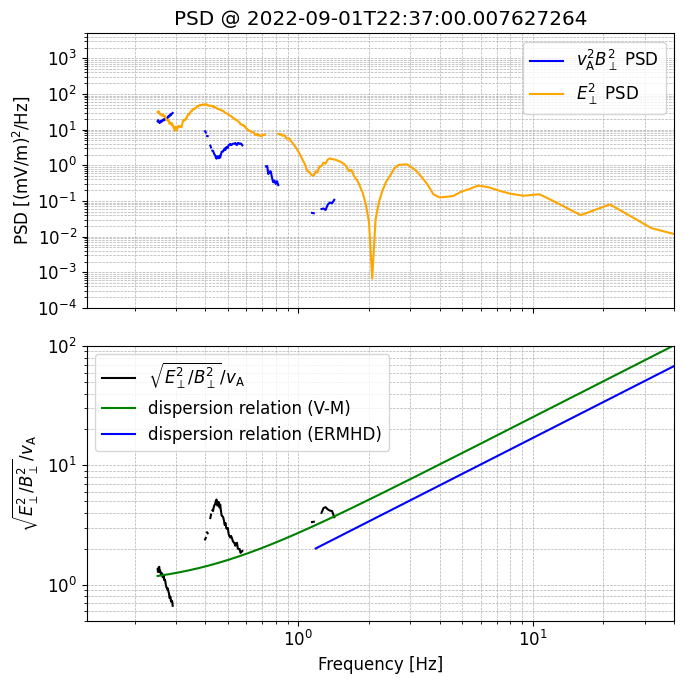

: 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pytplot as pt
import matplotlib as mpl

mpl.rcdefaults()
mpl.rcParams['font.size'] = 12

target_time_str = '2022-09-01T22:37:00'

Bx_psd  = pt.data_quants['B_fac_x_hp_clean']
By_psd  = pt.data_quants['B_fac_y_hp_clean']
Ex_psd  = pt.data_quants['E_fac_x_hp_clean']
Ey_psd  = pt.data_quants['E_fac_y_hp_clean']
v_A_    = pt.data_quants['Alfven_speed'] * 1E3

t0      = np.datetime64(target_time_str)
idx     = np.argmin(np.abs(Bx_psd.time.values - t0))      # 最近傍インデックス
freq    = Bx_psd.v.values                      # 周波数軸 [Hz]

cutoff_freq = 1/6 # 1/6 Hz 以下の成分は除去する
mask = Bx_psd['spec_bins'] >= cutoff_freq          # True/False の配列
Bx_psd = Bx_psd.isel(v_dim=mask)
By_psd = By_psd.isel(v_dim=mask)
Ex_psd = Ex_psd.isel(v_dim=mask)
Ey_psd = Ey_psd.isel(v_dim=mask)
freq = freq[mask]  # 周波数軸も更新

B_perp2 = Bx_psd.values + By_psd.values
E_perp2 = Ex_psd.values + Ey_psd.values

# 1. 解析対象スロット（idx）の PSD を取り出し
B_perp2_slice = (Bx_psd[idx, :].values + By_psd[idx, :].values) * 1E-18         # [T^2/Hz]
E_perp2_slice = (Ex_psd[idx, :].values + Ey_psd[idx, :].values)                 # [(mV/m)^2/Hz]

# 2. 同時刻の Alfven 速度を取得（cm-3 → m-3 換算済みのものを使っている前提）
v_A_val = v_A_.interp(time=t0).values      # [m/s]


# 3. v_A^2 * E_perp^2  を計算
#    E の単位が mV/m なら V/m へ換算する必要あり → (1e-3)^2 = 1e-6
VA2_Bperp2_slice = (v_A_val**2) * (B_perp2_slice) * 1E6     # [(mV/m)^2/Hz]

print(VA2_Bperp2_slice.shape, E_perp2_slice.shape, freq.shape)

ratio_dimless = np.sqrt(E_perp2_slice * 1e-6 / B_perp2_slice) / v_A_val
#   E_perp2: (mV/m)2 → (V/m)2 に 1e-6 変換

# dispersion relation
ion_cyclo_freq = pt.data_quants['ion_cyclo_freq'].interp(time=t0).values  # [Hz]
V_ion_fac_perp = pt.data_quants['erg_lepi_l2_3dflux_FPDU_velocity_fac_perp'].interp(time=t0).values
V_th_proton = pt.data_quants['V_th_proton'].interp(time=t0).values
C_s_proton = pt.data_quants['C_s_proton'].interp(time=t0).values
E_B_v_A_ratio_VB = (1E0 + (freq / ion_cyclo_freq * V_th_proton / V_ion_fac_perp)**2E0) / np.sqrt(1E0 + (freq / ion_cyclo_freq)**2E0 * ((C_s_proton / V_ion_fac_perp)**2E0 + (V_th_proton / V_ion_fac_perp)**2E0))

tau = (V_th_proton / C_s_proton)**2E0 / 2E0
beta_i = (V_th_proton / v_A_val)**2E0

def dispersion_relation_ERMHD(freq):
    """
    すべて ndarray (もしくはブロードキャスト可能な形) を想定。
    戻り値は freq と同じ形の ndarray。
    """
    kperp_rhoi = (freq / ion_cyclo_freq) * (V_th_proton / V_ion_fac_perp)

    # 高k域の式
    high_val = kperp_rhoi * tau / np.sqrt((beta_i * (1.0 + tau) + 2.0 * tau) * (1.0 + tau))

    # 条件ごとの値を np.select で選ぶ
    conds    = [kperp_rhoi < np.sqrt(0.1),
                kperp_rhoi > np.sqrt(10.0)]
    choices  = [np.ones_like(kperp_rhoi), high_val]
    result   = np.select(conds, choices, default=np.nan)

    return result

E_B_v_A_ratio_ERMHD = dispersion_relation_ERMHD(freq)



# 4. プロット 2 枚（上下サブプロット） ------------------------------
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 7), sharex=True,
                               gridspec_kw={'height_ratios': [1, 1]})

# --- (a) 既存の v_A2B⊥2 と E⊥2 -----------------------------------
ax1.loglog(freq, VA2_Bperp2_slice, label=r'$v_\mathrm{A}^{2}B_\perp^{2}$ PSD', color='b')
ax1.loglog(freq, E_perp2_slice,    label=r'$E_\perp^{2}$ PSD', color='orange')
ax1.set_ylabel(r'PSD [$(\mathrm{mV/m})^{2}$/Hz]')
ax1.set_title(f'PSD @ {np.datetime_as_string(Bx_psd.time.values[idx], unit="ns")}')
ax1.grid(True, which='both', ls='--', lw=0.5)
ax1.set_ylim(1e-4, 5e3)
ax1.set_xlim(1/8, 4e1)
ax1.legend()

# --- (b) 無次元比 √(E⊥2/B⊥2)/v_A -----------------------------------
ax2.loglog(freq, ratio_dimless, color='k', label=r'$\sqrt{E_\perp^{2}/B_\perp^{2}}/v_{\mathrm{A}}$')
ax2.loglog(freq, E_B_v_A_ratio_VB, color='green', label=r'dispersion relation (V-M)')
ax2.loglog(freq, E_B_v_A_ratio_ERMHD, color='blue', label=r'dispersion relation (ERMHD)')
ax2.set_xlabel('Frequency [Hz]')
ax2.set_ylabel(r'$\sqrt{E_\perp^{2}/B_\perp^{2}}/v_{\mathrm{A}}$')
ax2.grid(True, which='both', ls='--', lw=0.5)
ax2.set_ylim(5E-1, 1E2)
ax2.legend()

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import pandas as pd
from joblib import Parallel, delayed
import os
import matplotlib as mpl
import sys
sys.path.append("..")
import module_handmade.psd_plotter as pp
importlib.reload(pp)

mpl.rcdefaults()
mpl.rcParams['font.size'] = 12

# ------------------------------------------------------------
# 0. 出力フォルダの用意
# ------------------------------------------------------------
out_dir = '/mnt/j/KAW_observation/E_B_ratio_ERG/2022-09-01/22-24_cleaned_CWT_1sec_avg'
os.makedirs(out_dir, exist_ok=True)

# ------------------------------------------------------------
# 1. データの読み込みと準備（モジュール関数を呼び出す）
# ------------------------------------------------------------
data_dict = pp.load_and_prepare_data(cutoff_freq=1/6)

if data_dict is None:
    print("データ準備に失敗したため、処理を終了します。")
    exit()

# ------------------------------------------------------------
# 2. 解析対象の時間を決め、1秒ごとにループ
# ------------------------------------------------------------

def process_and_save_plot(t_start, data_dict, out_dir):
    """
    指定された単一の時刻について、スペクトルをプロットし、画像を保存する関数。
    """
    # モジュール関数を呼び出してプロットを作成
    # psd_plotter を pp としてインポートしている前提
    fig = pp.plot_averaged_spectrum(t_start, data_dict, interval_sec=1, n_samples_mc=200) # MCサンプル数を減らしておく
    
    # figがNoneでなければ（データがあってプロットが作成されれば）保存
    if fig is not None:
        try:
            # ファイル名に使いやすいように文字列に変換
            fname = pd.Timestamp(t_start).strftime('%Y-%m-%dT%H%M%S.png')
            fig.savefig(os.path.join(out_dir, fname), dpi=200)
        finally:
            # 保存に失敗しても、メモリ解放のために必ずクローズする
            plt.close(fig)

time_range = ['2022-09-01T22:30:00', '2022-09-01T23:30:00']
t_min, t_max = pd.to_datetime(time_range)

# pandas.date_rangeで1秒ごとのタイムスタンプを生成
time_steps = pd.date_range(start=t_min, end=t_max, freq='1s')

print(f"Processing {len(time_steps)} plots in parallel...")

# forループの代わりにParallelを呼び出す
Parallel(n_jobs=-1, verbose=10)(
    delayed(process_and_save_plot)(t_start, data_dict, out_dir) for t_start in time_steps
)

print('Finished saving all plots!')

Processing 3601 plots in parallel...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pytplot as pt
import matplotlib as mpl

mpl.rcdefaults()
mpl.rcParams['font.size'] = 12


# ------------------------------------------------------------
# 0. 出力フォルダの用意
# ------------------------------------------------------------
out_dir = '/mnt/j/KAW_observation/E_B_ratio_ERG/2022-09-01/22-24_cleaned_CWT'
os.makedirs(out_dir, exist_ok=True)      # すでにあっても OK

# ------------------------------------------------------------
# 1. 対象データの読み出し
# ------------------------------------------------------------
Bx_psd = pt.data_quants['B_fac_x_hp_clean']
By_psd = pt.data_quants['B_fac_y_hp_clean']
Ex_psd = pt.data_quants['E_fac_x_hp_clean']
Ey_psd = pt.data_quants['E_fac_y_hp_clean']
v_A_   = pt.data_quants['Alfven_speed'] * 1E3

freq = Bx_psd.v.values        # 共通周波数軸 [Hz]

cutoff_freq = 1/6 # 1/6 Hz 以下の成分は除去する
mask = Bx_psd['spec_bins'] >= cutoff_freq          # True/False の配列
Bx_psd = Bx_psd.isel(v_dim=mask)
By_psd = By_psd.isel(v_dim=mask)
Ex_psd = Ex_psd.isel(v_dim=mask)
Ey_psd = Ey_psd.isel(v_dim=mask)
freq = freq[mask]  # 周波数軸も更新

# ------------------------------------------------------------
# 2. 解析対象の time_range を決めてループ
#    例: time_range = ['2022-09-01T03:49:00', '2022-09-01T03:59:00']
# ------------------------------------------------------------
time_range = ['2022-09-01T23:05:50', '2022-09-01T23:30:00']
t_min, t_max = map(np.datetime64, time_range)

for t in Bx_psd.time.values:
    if not (t_min <= t <= t_max):
        continue

    idx = np.argmin(np.abs(Bx_psd.time.values - t))

    # --- PSD スライス --------------------------------------------------
    B_perp2_slice = (Bx_psd[idx, :].values + By_psd[idx, :].values) * 1e-18  # [T2/Hz]
    E_perp2_slice = (Ex_psd[idx, :].values + Ey_psd[idx, :].values)          # [(mV/m)2/Hz]

    v_A_val = v_A_.interp(time=t).values

    VA2_Bperp2_slice = (v_A_val**2) * B_perp2_slice * 1e6                   # [(mV/m)2/Hz]
    ratio_dimless    = np.sqrt(E_perp2_slice * 1e-6 / B_perp2_slice) / v_A_val

    # dispersion relation
    ion_cyclo_freq = pt.data_quants['ion_cyclo_freq'].interp(time=t).values  # [Hz]
    V_ion_fac_perp = pt.data_quants['erg_lepi_l2_3dflux_FPDU_velocity_fac_perp'].interp(time=t).values
    V_th_proton = pt.data_quants['V_th_proton'].interp(time=t).values
    C_s_proton = pt.data_quants['C_s_proton'].interp(time=t).values

    E_B_v_A_ratio_VB = (1E0 + (freq / ion_cyclo_freq * V_th_proton / V_ion_fac_perp)**2E0) / np.sqrt(1E0 + (freq / ion_cyclo_freq)**2E0 * ((C_s_proton / V_ion_fac_perp)**2E0 + (V_th_proton / V_ion_fac_perp)**2E0))

    tau = (V_th_proton / C_s_proton)**2E0 / 2E0
    beta_i = (V_th_proton / v_A_val)**2E0

    def dispersion_relation_ERMHD(freq):
        """
        すべて ndarray (もしくはブロードキャスト可能な形) を想定。
        戻り値は freq と同じ形の ndarray。
        """
        kperp_rhoi = (freq / ion_cyclo_freq) * (V_th_proton / V_ion_fac_perp)

        # 高k域の式
        high_val = kperp_rhoi * tau / np.sqrt((beta_i * (1.0 + tau) + 2.0 * tau) * (1.0 + tau))

        # 条件ごとの値を np.select で選ぶ
        conds    = [kperp_rhoi < np.sqrt(0.1),
                    kperp_rhoi > np.sqrt(10.0)]
        choices  = [np.ones_like(kperp_rhoi), high_val]
        result   = np.select(conds, choices, default=np.nan)

        return result

    E_B_v_A_ratio_ERMHD = dispersion_relation_ERMHD(freq)

    # --- プロット ------------------------------------------------------
    fig, (ax1, ax2) = plt.subplots(
        2, 1, figsize=(7, 7), sharex=True,
        gridspec_kw={'height_ratios': [1, 1]}
    )

    ax1.loglog(freq, VA2_Bperp2_slice, label=r'$v_\mathrm{A}^{2}B_\perp^{2}$ PSD', color='b')
    ax1.loglog(freq, E_perp2_slice,    label=r'$E_\perp^{2}$ PSD', color='orange')
    ax1.set_ylabel(r'PSD [$(\mathrm{mV/m})^{2}$/Hz]')
    ax1.set_title(f'PSD @ {np.datetime_as_string(t, unit="ns")}')
    ax1.grid(True, which='both', ls='--', lw=0.5)
    ax1.set_ylim(1e-4, 5e3)
    ax1.set_xlim(1/8, 4e1)
    ax1.legend(fontsize=10)

    ax2.loglog(freq, ratio_dimless, color='k', label=r'$\sqrt{E_\perp^{2}/B_\perp^{2}}/v_{\mathrm{A}}$')
    ax2.loglog(freq, E_B_v_A_ratio_VB, color='green', label=r'dispersion relation (V-M)')
    ax2.loglog(freq, E_B_v_A_ratio_ERMHD, color='blue', label=r'dispersion relation (ERMHD)')
    ax2.legend(fontsize=10)
    ax2.set_xlabel('Frequency [Hz]')
    ax2.set_ylabel(r'$\sqrt{E_\perp^{2}/B_\perp^{2}}/v_{\mathrm{A}}$')
    ax2.grid(True, which='both', ls='--', lw=0.5)
    ax2.set_ylim(5e-1, 1e2)
    ax2.set_xlim(1/8, 4e1)

    plt.tight_layout()

    # --- 画像保存 ------------------------------------------------------
    fname = f'{np.datetime_as_string(t, unit="ns")}.png'
    fig.savefig(os.path.join(out_dir, fname), dpi=200)
    plt.close(fig)      # メモリ解放

print('Finished saving all plots!')


25-Jul-25 14:13:26: Substituting symbol \perp from STIXGeneral
25-Jul-25 14:13:26: Substituting symbol \perp from STIXGeneral
25-Jul-25 14:13:26: Substituting symbol \perp from STIXGeneral
25-Jul-25 14:13:26: Substituting symbol \perp from STIXGeneral
25-Jul-25 14:13:27: Substituting symbol \perp from STIXGeneral
25-Jul-25 14:13:27: Substituting symbol \perp from STIXGeneral
25-Jul-25 14:13:27: Substituting symbol \perp from STIXGeneral
25-Jul-25 14:13:27: Substituting symbol \perp from STIXGeneral
25-Jul-25 14:13:27: Substituting symbol \perp from STIXGeneral
25-Jul-25 14:13:27: Substituting symbol \perp from STIXGeneral
25-Jul-25 14:13:27: Substituting symbol \perp from STIXGeneral
25-Jul-25 14:13:27: Substituting symbol \perp from STIXGeneral
25-Jul-25 14:13:27: Substituting symbol \perp from STIXGeneral
25-Jul-25 14:13:27: Substituting symbol \perp from STIXGeneral
25-Jul-25 14:13:27: Substituting symbol \perp from STIXGeneral
25-Jul-25 14:13:27: Substituting symbol \perp from STIX

Finished saving all plots!


In [22]:
import os
from natsort import natsorted
import imageio                # ← v3 なら imageio.v2 を付けなくても同じ

img_dir = '/mnt/j/KAW_observation/E_B_ratio_ERG/2022-09-01/22-24_cleaned_dprt_kperprhoi'
png_files = natsorted([os.path.join(img_dir, f)
                       for f in os.listdir(img_dir)
                       if f.lower().endswith('.png')])

frames = [imageio.imread(f) for f in png_files]
out_path = os.path.join(img_dir, 'E_B_ratio_ERG.mp4')

# codec は imageio-ffmpeg の同梱バイナリが自動で使われる
imageio.mimsave(out_path, frames, fps=5, codec='libx264')
print('saved to', out_path)

24-Jul-25 16:27:36: /tmp/ipykernel_1465/1605854286.py:10: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  frames = [imageio.imread(f) for f in png_files]

24-Jul-25 16:28:42: IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (1400, 1400) to (1408, 1408) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


saved to /mnt/j/KAW_observation/E_B_ratio_ERG/2022-09-01/22-24_cleaned_dprt_kperprhoi/E_B_ratio_ERG.mp4


## 横軸を$k_{\perp} \rho_{\mathrm{i}} \approx \frac{f_{\mathrm{sc}}}{f_{\mathrm{ci}}} \, \frac{v_{\mathrm{thi}}}{V_{\perp \mathrm{flow}}}$に設定

(510,) (510,) (510,)


30-Jul-25 18:16:55: Substituting symbol \perp from STIXGeneral
30-Jul-25 18:16:55: Substituting symbol \perp from STIXGeneral
30-Jul-25 18:16:55: Substituting symbol \perp from STIXGeneral
30-Jul-25 18:16:55: Substituting symbol \perp from STIXGeneral
30-Jul-25 18:16:55: Substituting symbol \perp from STIXGeneral
30-Jul-25 18:16:55: Substituting symbol \perp from STIXGeneral
30-Jul-25 18:16:55: Substituting symbol \perp from STIXGeneral
30-Jul-25 18:16:55: Substituting symbol \perp from STIXGeneral
30-Jul-25 18:16:55: Substituting symbol \perp from STIXGeneral
30-Jul-25 18:16:55: Substituting symbol \perp from STIXGeneral
30-Jul-25 18:16:55: Substituting symbol \perp from STIXGeneral
30-Jul-25 18:16:55: Substituting symbol \perp from STIXGeneral
30-Jul-25 18:16:55: Substituting symbol \perp from STIXGeneral
30-Jul-25 18:16:55: Substituting symbol \perp from STIXGeneral
30-Jul-25 18:16:55: Substituting symbol \perp from STIXGeneral
30-Jul-25 18:16:55: Substituting symbol \perp from STIX

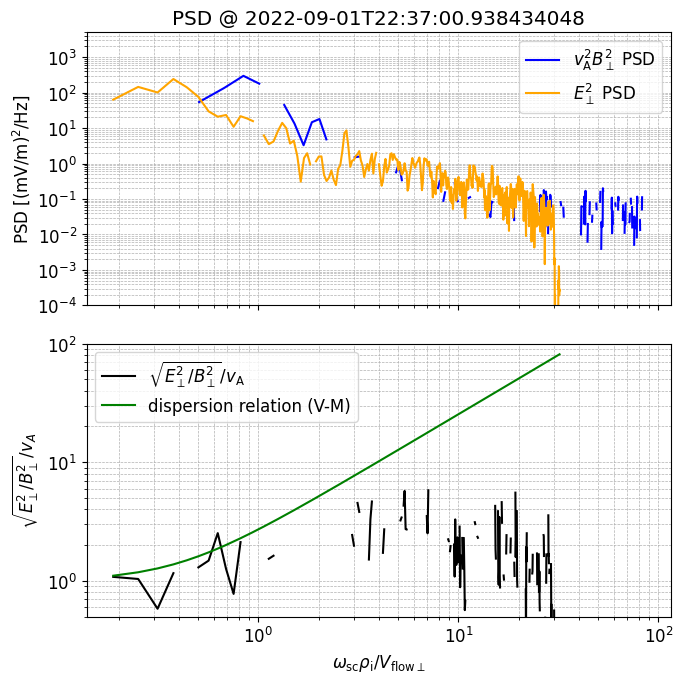

In [76]:
import numpy as np
import matplotlib.pyplot as plt
import pytplot as pt
import matplotlib as mpl

mpl.rcdefaults()

mpl.rcParams['font.size'] = 12

target_time_str = '2022-09-01T22:37:00'

Bx_psd  = pt.data_quants['B_fac_x_hp_clean']
By_psd  = pt.data_quants['B_fac_y_hp_clean']
Ex_psd  = pt.data_quants['E_fac_x_hp_clean']
Ey_psd  = pt.data_quants['E_fac_y_hp_clean']
v_A_    = pt.data_quants['Alfven_speed'] * 1E3

t0      = np.datetime64(target_time_str)
idx     = np.argmin(np.abs(Bx_psd.time.values - t0))      # 最近傍インデックス

freq = Bx_psd.v.values        # 共通周波数軸 [Hz]

cutoff_freq = 1/6 # 1/6 Hz 以下の成分は除去する
mask = Bx_psd['spec_bins'] >= cutoff_freq          # True/False の配列
Bx_psd = Bx_psd.isel(v_dim=mask)
By_psd = By_psd.isel(v_dim=mask)
Ex_psd = Ex_psd.isel(v_dim=mask)
Ey_psd = Ey_psd.isel(v_dim=mask)
freq = freq[mask]  # 周波数軸も更新

B_perp2 = Bx_psd.values + By_psd.values
E_perp2 = Ex_psd.values + Ey_psd.values

# 1. 解析対象スロット（idx）の PSD を取り出し
B_perp2_slice = (Bx_psd[idx, :].values + By_psd[idx, :].values) * 1E-18         # [T^2/Hz]
E_perp2_slice = (Ex_psd[idx, :].values + Ey_psd[idx, :].values)                 # [(mV/m)^2/Hz]

# 2. 同時刻の Alfven 速度を取得（cm-3 → m-3 換算済みのものを使っている前提）
v_A_val = v_A_.interp(time=t0).values      # [m/s]


# 3. v_A^2 * E_perp^2  を計算
#    E の単位が mV/m なら V/m へ換算する必要あり → (1e-3)^2 = 1e-6
VA2_Bperp2_slice = (v_A_val**2) * (B_perp2_slice) * 1E6     # [(mV/m)^2/Hz]

print(VA2_Bperp2_slice.shape, E_perp2_slice.shape, freq.shape)

ratio_dimless = np.sqrt(E_perp2_slice * 1e-6 / B_perp2_slice) / v_A_val
#   E_perp2: (mV/m)2 → (V/m)2 に 1e-6 変換

# dispersion relation
ion_cyclo_freq = pt.data_quants['ion_cyclo_freq'].interp(time=t0).values  # [Hz]
V_ion_fac_perp = pt.data_quants['erg_lepi_l2_3dflux_FPDU_velocity_fac_perp'].interp(time=t0).values
V_th_proton = pt.data_quants['V_th_proton'].interp(time=t0).values
C_s_proton = pt.data_quants['C_s_proton'].interp(time=t0).values

kperp_rhoi = freq / ion_cyclo_freq * V_th_proton / V_ion_fac_perp

E_B_v_A_ratio = (1E0 + kperp_rhoi**2E0) / np.sqrt(1E0 + kperp_rhoi**2E0 * (1E0 + (C_s_proton / V_th_proton)**2E0))

# 4. プロット 2 枚（上下サブプロット） ------------------------------
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 7), sharex=True,
                               gridspec_kw={'height_ratios': [1, 1]})

# --- (a) 既存の v_A2B⊥2 と E⊥2 -----------------------------------
ax1.loglog(kperp_rhoi, VA2_Bperp2_slice, label=r'$v_\mathrm{A}^{2}B_\perp^{2}$ PSD', color='b')
ax1.loglog(freq, E_perp2_slice,    label=r'$E_\perp^{2}$ PSD', color='orange')
ax1.set_ylabel(r'PSD [$(\mathrm{mV/m})^{2}$/Hz]')
ax1.set_title(f'PSD @ {np.datetime_as_string(Bx_psd.time.values[idx], unit="ns")}')
ax1.grid(True, which='both', ls='--', lw=0.5)
ax1.set_ylim(1e-4, 5e3)
ax1.legend()

# --- (b) 無次元比 √(E⊥2/B⊥2)/v_A -----------------------------------
ax2.loglog(freq, ratio_dimless, color='k', label=r'$\sqrt{E_\perp^{2}/B_\perp^{2}}/v_{\mathrm{A}}$')
ax2.loglog(freq, E_B_v_A_ratio_VB, color='green', label=r'dispersion relation (V-M)')
ax2.legend()
ax2.set_xlabel(r'$\omega_{\mathrm{sc}} \rho_{\mathrm{i}} / V_{\mathrm{flow}\perp}$')
ax2.set_ylabel(r'$\sqrt{E_\perp^{2}/B_\perp^{2}}/v_A$')
ax2.grid(True, which='both', ls='--', lw=0.5)
ax2.set_ylim(5E-1, 1E2)

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pytplot as pt
import matplotlib as mpl

mpl.rcdefaults()

mpl.rcParams['font.size'] = 12

# ------------------------------------------------------------
# 0. 出力フォルダの用意
# ------------------------------------------------------------
out_dir = '/mnt/j/KAW_observation/E_B_ratio_ERG/2022-09-01/22-24_cleaned_dprt_kperprhoi'
os.makedirs(out_dir, exist_ok=True)      # すでにあっても OK

# ------------------------------------------------------------
# 1. 対象データの読み出し
# ------------------------------------------------------------
Bx_psd = pt.data_quants['B_fac_x_hp_clean']
By_psd = pt.data_quants['B_fac_y_hp_clean']
Ex_psd = pt.data_quants['E_fac_x_hp_clean']
Ey_psd = pt.data_quants['E_fac_y_hp_clean']
v_A_   = pt.data_quants['Alfven_speed'] *1E3

freq = Bx_psd.v.values        # 共通周波数軸 [Hz]
print(freq)

cutoff_freq = 1/6 # 1/6 Hz 以下の成分は除去する
mask = Bx_psd['spec_bins'] >= cutoff_freq          # True/False の配列
Bx_psd = Bx_psd.isel(v_dim=mask)
By_psd = By_psd.isel(v_dim=mask)
Ex_psd = Ex_psd.isel(v_dim=mask)
Ey_psd = Ey_psd.isel(v_dim=mask)
freq = freq[mask]  # 周波数軸も更新

# ------------------------------------------------------------
# 2. 解析対象の time_range を決めてループ
#    例: time_range = ['2022-09-01T03:49:00', '2022-09-01T03:59:00']
# ------------------------------------------------------------
time_range = ['2022-09-01T23:27:57', '2022-09-01T23:30:00']
t_min, t_max = map(np.datetime64, time_range)

for t in Bx_psd.time.values:
    if not (t_min <= t <= t_max):
        continue

    idx = np.argmin(np.abs(Bx_psd.time.values - t))

    # --- PSD スライス --------------------------------------------------
    B_perp2_slice = (Bx_psd[idx, :].values + By_psd[idx, :].values) * 1e-18  # [T2/Hz]
    E_perp2_slice = (Ex_psd[idx, :].values + Ey_psd[idx, :].values)          # [(mV/m)2/Hz]

    v_A_val = v_A_.interp(time=t).values

    VA2_Bperp2_slice = (v_A_val**2) * B_perp2_slice * 1e6                   # [(mV/m)2/Hz]
    ratio_dimless    = np.sqrt(E_perp2_slice * 1e-6 / B_perp2_slice) / v_A_val

    # dispersion relation
    ion_cyclo_freq = pt.data_quants['ion_cyclo_freq'].interp(time=t).values  # [Hz]
    V_ion_fac_perp = pt.data_quants['erg_lepi_l2_3dflux_FPDU_velocity_fac_perp'].interp(time=t).values
    V_th_proton = pt.data_quants['V_th_proton'].interp(time=t).values
    C_s_proton = pt.data_quants['C_s_proton'].interp(time=t).values

    tau = (V_th_proton / C_s_proton)**2E0 / 2E0
    beta_i = (V_th_proton / v_A_val)**2E0

    kperp_rhoi_ob = freq / ion_cyclo_freq * V_th_proton / V_ion_fac_perp
    kperp_rhoi_th = np.logspace(-1, 2, 10000)
    tau = (V_th_proton / C_s_proton)**2E0 / 2E0
    beta_i = (V_th_proton / v_A_val)**2E0

    E_B_v_A_ratio_VB = (1E0 + kperp_rhoi_th**2E0) / np.sqrt(1E0 + kperp_rhoi_th**2E0 * (1E0 + (C_s_proton / V_th_proton)**2E0))


    def dispersion_relation_ERMHD(kperp_rhoi):
        """
        すべて ndarray (もしくはブロードキャスト可能な形) を想定。
        戻り値は freq と同じ形の ndarray。
        """

        # 高k域の式
        high_val = kperp_rhoi * tau / np.sqrt((beta_i * (1.0 + tau) + 2.0 * tau) * (1.0 + tau))

        # 条件ごとの値を np.select で選ぶ
        conds    = [kperp_rhoi < np.sqrt(0.1),
                    kperp_rhoi > np.sqrt(10.0)]
        choices  = [np.ones_like(kperp_rhoi), high_val]
        result   = np.select(conds, choices, default=np.nan)

        return result

    E_B_v_A_ratio_ERMHD = dispersion_relation_ERMHD(kperp_rhoi_th)

    # --- プロット ------------------------------------------------------
    fig, (ax1, ax2) = plt.subplots(
        2, 1, figsize=(7, 7), sharex=True,
        gridspec_kw={'height_ratios': [1, 1]}
    )

    ax1.loglog(kperp_rhoi_ob, VA2_Bperp2_slice, label=r'$v_A^{2}B_\perp^{2}$ PSD', color='b')
    ax1.loglog(kperp_rhoi_ob, E_perp2_slice,    label=r'$E_\perp^{2}$ PSD', color='orange')
    ax1.set_ylabel(r'PSD [$(\mathrm{mV/m})^{2}$/Hz]')
    ax1.set_title(f'PSD @ {np.datetime_as_string(t, unit="ns")}')
    ax1.grid(True, which='both', ls='--', lw=0.5)
    ax1.set_ylim(1e-4, 5e3)
    ax1.set_xlim(1e-1, 1e2)
    ax1.legend()

    ax2.loglog(kperp_rhoi_ob, ratio_dimless, color='k', label=r'$\sqrt{E_\perp^{2}/B_\perp^{2}}/v_A$')
    ax2.loglog(kperp_rhoi_th, E_B_v_A_ratio_VB, color='green', label=r'dispersion relation (V-M)')
    ax2.loglog(kperp_rhoi_th, E_B_v_A_ratio_ERMHD, color='blue', label=r'dispersion relation (ERMHD)')
    ax2.legend()
    ax2.set_xlabel(r'$\omega_{\mathrm{sc}} \rho_{\mathrm{i}} / |V_{\mathrm{flow}\perp}|$')
    ax2.set_ylabel(r'$\sqrt{E_\perp^{2}/B_\perp^{2}}/v_{\mathrm{A}}$')
    ax2.grid(True, which='both', ls='--', lw=0.5)
    ax2.set_ylim(5e-1, 1e2)
    ax2.set_xlim(1e-1, 1e2)

    plt.tight_layout()

    # --- 画像保存 ------------------------------------------------------
    fname = f'{np.datetime_as_string(t, unit="ns")}.png'
    fig.savefig(os.path.join(out_dir, fname), dpi=200)
    plt.close(fig)      # メモリ解放

print('Finished saving all plots!')
print('Finished saving all plots!')

[ 0.06259934  0.12519868  0.18779802  0.25039736  0.3129967   0.37559604
  0.43819538  0.50079472  0.56339406  0.6259934   0.68859274  0.75119208
  0.81379142  0.87639076  0.9389901   1.00158944  1.06418878  1.12678812
  1.18938746  1.2519868   1.31458614  1.37718547  1.43978481  1.50238415
  1.56498349  1.62758283  1.69018217  1.75278151  1.81538085  1.87798019
  1.94057953  2.00317887  2.06577821  2.12837755  2.19097689  2.25357623
  2.31617557  2.37877491  2.44137425  2.50397359  2.56657293  2.62917227
  2.69177161  2.75437095  2.81697029  2.87956963  2.94216897  3.00476831
  3.06736765  3.12996699  3.19256633  3.25516567  3.31776501  3.38036435
  3.44296369  3.50556303  3.56816237  3.63076171  3.69336105  3.75596039
  3.81855973  3.88115907  3.94375841  4.00635775  4.06895709  4.13155642
  4.19415576  4.2567551   4.31935444  4.38195378  4.44455312  4.50715246
  4.5697518   4.63235114  4.69495048  4.75754982  4.82014916  4.8827485
  4.94534784  5.00794718  5.07054652  5.13314586  5.

25-Jul-25 15:05:20: Substituting symbol \perp from STIXGeneral
25-Jul-25 15:05:20: Substituting symbol \perp from STIXGeneral
25-Jul-25 15:05:20: Substituting symbol \perp from STIXGeneral
25-Jul-25 15:05:20: Substituting symbol \perp from STIXGeneral
25-Jul-25 15:05:20: Substituting symbol \perp from STIXGeneral
25-Jul-25 15:05:20: Substituting symbol \perp from STIXGeneral
25-Jul-25 15:05:20: Substituting symbol \perp from STIXGeneral
25-Jul-25 15:05:20: Substituting symbol \perp from STIXGeneral
25-Jul-25 15:05:20: Substituting symbol \perp from STIXGeneral
25-Jul-25 15:05:20: Substituting symbol \perp from STIXGeneral
25-Jul-25 15:05:20: Substituting symbol \perp from STIXGeneral
25-Jul-25 15:05:20: Substituting symbol \perp from STIXGeneral
25-Jul-25 15:05:20: Substituting symbol \perp from STIXGeneral
25-Jul-25 15:05:20: Substituting symbol \perp from STIXGeneral
25-Jul-25 15:05:20: Substituting symbol \perp from STIXGeneral
25-Jul-25 15:05:20: Substituting symbol \perp from STIX

Finished saving all plots!
Finished saving all plots!


# パワースペクトルの時間平均をとる

[[3.55278236e+01            nan 3.12086984e+00 ... 2.88128122e-04
  1.92520456e-03 1.25211558e-03]
 [6.38030543e+01 3.82385282e+01 5.99756343e+00 ... 1.20954457e-03
  2.92696651e-03 1.65503370e-03]
 [7.69306848e+01 4.82744049e+01 2.04124895e+01 ... 2.79485483e-03
  2.21337948e-03 1.40957753e-03]
 ...
 [4.11566357e+01 1.15138292e+02 1.90358804e+02 ... 9.54184685e-04
  7.54470077e-04 5.83402202e-04]
 [           nan 1.08447572e+02 7.15546706e+01 ... 2.75061127e-04
  1.13432803e-04 2.57785959e-04]
 [3.09941005e+01 1.13269753e+02 8.97728143e+00 ...            nan
  9.48109532e-05 1.67582374e-04]]


30-Jul-25 18:26:24: Substituting symbol \perp from STIXGeneral
30-Jul-25 18:26:24: Substituting symbol \perp from STIXGeneral
30-Jul-25 18:26:24: Substituting symbol \perp from STIXGeneral
30-Jul-25 18:26:24: Substituting symbol \perp from STIXGeneral
30-Jul-25 18:26:24: Substituting symbol \perp from STIXGeneral
30-Jul-25 18:26:24: Substituting symbol \perp from STIXGeneral
30-Jul-25 18:26:24: Substituting symbol \perp from STIXGeneral
30-Jul-25 18:26:24: Substituting symbol \perp from STIXGeneral
30-Jul-25 18:26:25: Substituting symbol \perp from STIXGeneral
30-Jul-25 18:26:25: Substituting symbol \perp from STIXGeneral
30-Jul-25 18:26:25: Substituting symbol \perp from STIXGeneral
30-Jul-25 18:26:25: Substituting symbol \perp from STIXGeneral
30-Jul-25 18:26:25: Substituting symbol \perp from STIXGeneral
30-Jul-25 18:26:25: Substituting symbol \perp from STIXGeneral
30-Jul-25 18:26:25: Substituting symbol \perp from STIXGeneral
30-Jul-25 18:26:25: Substituting symbol \perp from STIX

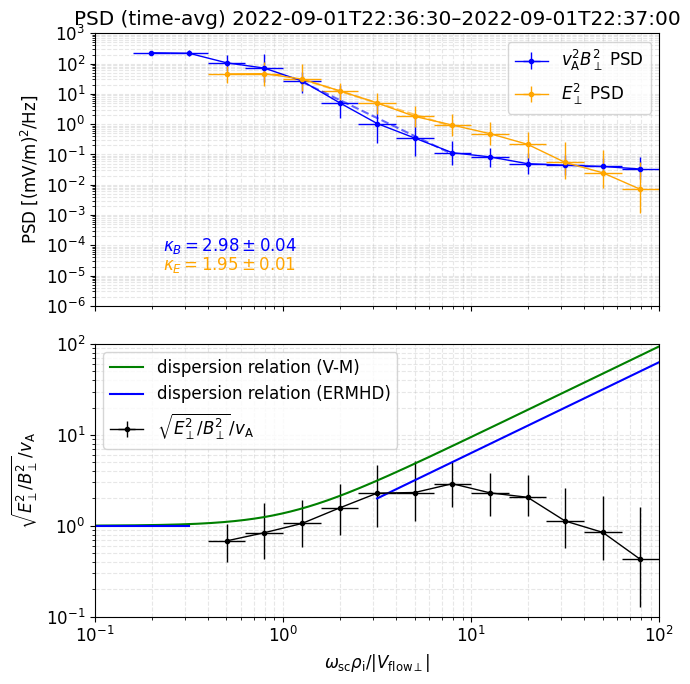

In [83]:
import numpy as np
import matplotlib.pyplot as plt
import pytplot as pt
import matplotlib as mpl
import xarray as xr
from scipy.stats import chi2, linregress, t

# -----------------------------------------------------------
# 0. matplotlib 設定
# -----------------------------------------------------------
mpl.rcdefaults()
mpl.rcParams['font.size'] = 12

# -----------------------------------------------------------
# 1. もとの DataArray を取得
# -----------------------------------------------------------
Bx_psd  = pt.data_quants['B_fac_x_hp_clean']
By_psd  = pt.data_quants['B_fac_y_hp_clean']
Ex_psd  = pt.data_quants['E_fac_x_hp_clean']
Ey_psd  = pt.data_quants['E_fac_y_hp_clean']
v_A_    = pt.data_quants['Alfven_speed'] * 1E3

freq        = Bx_psd.v.values           # 周波数軸 [Hz]
cutoff_freq = 1/6                       # 1/6 Hz 以下カット

mask   = Bx_psd['spec_bins'] >= cutoff_freq
Bx_psd = Bx_psd.isel(v_dim=mask)
By_psd = By_psd.isel(v_dim=mask)
Ex_psd = Ex_psd.isel(v_dim=mask)
Ey_psd = Ey_psd.isel(v_dim=mask)
freq   = freq[mask]

# B/E の時間軸を一致させる（グリッドが微妙に違う可能性がある）
#Ex_psd = Ex_psd.interp(time=Bx_psd.time, method='linear')
#Ey_psd = Ey_psd.interp(time=Bx_psd.time, method='linear')

time_new = Bx_psd.time.values  # 以後この time 軸を基準にする

# -----------------------------------------------------------
# 2. 必要物理量を同じ時間軸へ補間
# -----------------------------------------------------------
ion_cyclo_freq = pt.data_quants['ion_cyclo_freq'].interp(time=time_new, method='linear')
V_ion_fac_perp = pt.data_quants['erg_lepi_l2_3dflux_FPDU_velocity_fac_perp'].interp(time=time_new, method='linear')
V_th_proton    = pt.data_quants['V_th_proton'].interp(time=time_new, method='linear')
C_s_proton     = pt.data_quants['C_s_proton'].interp(time=time_new, method='linear')

# tau, beta_i は時刻ごとに変動
tau    = (V_th_proton.values / C_s_proton.values)**2.0 / 2E0
beta_i = (V_th_proton.values / v_A_.interp(time=time_new, method='linear').values)**2.0

# -----------------------------------------------------------
# 3. k_perp * rho_i 軸（観測値）を計算
#    kperp_rhoi_ob = (ω_sc / ω_ci) * (V_th / |V_flow⊥|)
# -----------------------------------------------------------
f      = freq            # (nfreq,)
w_ci   = ion_cyclo_freq.values
vth_i  = V_th_proton.values
vperp  = V_ion_fac_perp.values

kperp_rhoi_ob = (f[None, :] / w_ci[:, None]) * (vth_i[:, None] / vperp[:, None])  # (time, freq)

# -----------------------------------------------------------
# 4. PSD 計算： v_A^2 B_perp^2 と E_perp^2
# -----------------------------------------------------------
vA2        = (v_A_.interp(time=time_new, method='linear').values**2)[:, None]  # (time,1)
VA2_Bperp2 = vA2 * (Bx_psd.values + By_psd.values) * 1e-12  # [(mV/m)^2/Hz]
E_perp2    = (Ex_psd.values + Ey_psd.values)                # [(mV/m)^2/Hz]

# -----------------------------------------------------------
# 5. 対象時間範囲を指定＆切り出し
# -----------------------------------------------------------
t0 = np.datetime64('2022-09-01T22:30:00') + np.timedelta64(30, 's') * 13
t1 = t0 + np.timedelta64(30, 's')

# DataArray にすることで .sel が楽
k_da   = xr.DataArray(kperp_rhoi_ob, coords={'time': time_new, 'freq': f}, dims=('time', 'freq'))
va2_da = xr.DataArray(VA2_Bperp2,    coords={'time': time_new, 'freq': f}, dims=('time', 'freq'))
e_da   = xr.DataArray(E_perp2,       coords={'time': time_new, 'freq': f}, dims=('time', 'freq'))

k_sel   = k_da.sel(time=slice(t0, t1)).values
VA2_sel = va2_da.sel(time=slice(t0, t1)).values
E_sel   = e_da.sel(time=slice(t0, t1)).values

print(E_sel)

# tau, beta_i, r = C_s/V_th も同じ時間窓で切り出し
idx_t   = (time_new >= t0) & (time_new <= t1)
tau_sel = tau[idx_t]
beta_sel= beta_i[idx_t]
r_sel   = (C_s_proton.values / V_th_proton.values)[idx_t]

# -----------------------------------------------------------
# 6. ログ等間隔の k⊥ρ_i グリッドを用意してビン詰め
#    → ビンごとに幾何平均と非対称エラーバー
# -----------------------------------------------------------
kmin, kmax = 1e-1, 1e2
nbin = 15
bin_edges   = np.logspace(np.log10(kmin), np.log10(kmax), nbin + 1)
bin_centers = np.sqrt(bin_edges[:-1] * bin_edges[1:])  # 幾何平均中心
xerr        = np.vstack([bin_centers - bin_edges[:-1], bin_edges[1:] - bin_centers])

def bin_fill(k_mat, y_mat, edges):
    """
    k_mat: (time, freq) の k_perp*rho_i
    y_mat: 同次元の PSD 等
    edges: bin_edges (1D)
    return: list of arrays in each bin
    """
    nb = len(edges) - 1
    res = [[] for _ in range(nb)]
    for k_row, y_row in zip(k_mat, y_mat):
        good = np.isfinite(k_row) & np.isfinite(y_row) & (k_row > 0)
        if not np.any(good):
            continue
        bidx = np.digitize(k_row[good], edges) - 1
        in_range = (bidx >= 0) & (bidx < nb)
        for y_i, bi in zip(y_row[good][in_range], bidx[in_range]):
            res[bi].append(y_i)
    return res

vals_VA2_bins = bin_fill(k_sel, VA2_sel, bin_edges)
vals_E_bins   = bin_fill(k_sel, E_sel,   bin_edges)

# PSD比 R = sqrt(E_perp^2 / (v_A^2 B_perp^2)) も同様にビン詰め
vals_R_bins = bin_fill(k_sel, np.sqrt(E_sel / VA2_sel), bin_edges)

# -----------------------------------------------------------
# 7. 幾何平均 + 非対称エラーバー（ログ空間分位点 or SEM など）
# -----------------------------------------------------------
def geom_stats(values, mode='quantile', alpha=0.32):
    """
    values : list/array (>0) のデータ
    mode   : 'sem' | 'sd' | 'quantile' | 'chi2'
    alpha  : 信頼区間幅 (0.32 → 68%区間)
    戻り値 : (geom_mean, err_low, err_high) すべて線形空間
    """
    arr = np.asarray(values, float)
    arr = arr[np.isfinite(arr) & (arr > 0)]
    if arr.size == 0:
        return np.nan, np.nan, np.nan

    if mode == 'chi2':
        mean_lin = np.mean(arr)
        M = arr.size  # 本来は独立セグメント数
        lower = mean_lin * (2*M) / chi2.ppf(1 - alpha/2, 2*M)
        upper = mean_lin * (2*M) / chi2.ppf(alpha/2,     2*M)
        return mean_lin, mean_lin - lower, upper - mean_lin

    # ここから幾何平均系
    logp = np.log10(arr)
    mu   = logp.mean()
    if mode == 'sem':
        se = logp.std(ddof=1) / np.sqrt(logp.size)
        lo, hi = mu - se, mu + se
    elif mode == 'sd':
        sd = logp.std(ddof=1)
        lo, hi = mu - sd, mu + sd
    elif mode == 'quantile':
        qlo, qhi = np.nanpercentile(logp, [100*alpha/2, 100*(1-alpha/2)])
        lo, hi = qlo, qhi
    else:
        raise ValueError("mode must be one of 'sem','sd','quantile','chi2'.")

    gm = 10**mu
    err_lo = gm - 10**lo
    err_hi = 10**hi - gm
    return gm, err_lo, err_hi

def stats_bins(list_of_lists, mode='quantile', alpha=0.32):
    gm, lo, hi = [], [], []
    for vals in list_of_lists:
        m, l, h = geom_stats(vals, mode=mode, alpha=alpha)
        gm.append(m); lo.append(l); hi.append(h)
    return np.array(gm), np.vstack([lo, hi])

gm_VA2, yerr_VA2 = stats_bins(vals_VA2_bins, mode='quantile', alpha=0.32)
gm_E,   yerr_E   = stats_bins(vals_E_bins,   mode='quantile', alpha=0.32)
gm_R,   yerr_R   = stats_bins(vals_R_bins,   mode='quantile', alpha=0.32)

def sanitize_err(err):
    err = np.nan_to_num(err, nan=0.0, posinf=0.0, neginf=0.0)
    return np.abs(err)

yerr_VA2 = sanitize_err(yerr_VA2)
yerr_E   = sanitize_err(yerr_E)
yerr_R   = sanitize_err(yerr_R)
xerr     = sanitize_err(xerr)

# -----------------------------------------------------------
# 8. 理論分散関係 (V-M, ERMHD) とそのエラーバンド
# -----------------------------------------------------------
# 8.1 時間窓で tau/beta/r の幾何平均＆CIを計算
gm_tau,  lo_tau,  hi_tau  = geom_stats(tau_sel,  mode='quantile', alpha=0.32)
gm_beta, lo_beta, hi_beta = geom_stats(beta_sel, mode='quantile', alpha=0.32)
gm_r,    lo_r,    hi_r    = geom_stats(r_sel,    mode='quantile', alpha=0.32)

# 8.2 理論用 kグリッド
k_th  = np.logspace(-1, 2, 1000)
k_th1 = np.logspace(-1, np.log10(np.sqrt(0.1)), 300)  # ERMHD 定数域
k_th4 = np.logspace(np.log10(np.sqrt(10)), 2, 300)    # ERMHD ∝k域

# 8.3 中心値での理論曲線
E_B_v_A_ratio_VB_c    = (1.0 + k_th**2) / np.sqrt(1.0 + k_th**2 * (1.0 + gm_r**2))
E_B_v_A_ratio_ERMHD_c1= np.ones_like(k_th1)
E_B_v_A_ratio_ERMHD_c4= k_th4 * gm_tau / np.sqrt((gm_beta*(1+gm_tau) + 2*gm_tau) * (1+gm_tau))

# 8.4 パラメータの不確かさをモンテカルロで伝播
def draw_lognormal(gm, lo, hi, size, rng):
    """幾何平均 gm と上下偏差 lo/hi (線形空間) → lognormal の μ,σ を推定してサンプル"""
    mu_log = np.log10(gm)
    sig_hi = np.log10(gm + hi) - mu_log if np.isfinite(hi) else 0.0
    sig_lo = mu_log - np.log10(gm - lo) if np.isfinite(lo) and (gm - lo) > 0 else sig_hi
    sigma  = np.nanmean([sig_hi, sig_lo])
    return 10**rng.normal(mu_log, sigma, size=size)

Nsamp = 2000
rng   = np.random.default_rng(42)
tau_s  = draw_lognormal(gm_tau,  lo_tau,  hi_tau,  Nsamp, rng)
beta_s = draw_lognormal(gm_beta, lo_beta, hi_beta, Nsamp, rng)
r_s    = draw_lognormal(gm_r,    lo_r,    hi_r,    Nsamp, rng)

# Monte-Carlo 評価
VB_samp  = (1.0 + k_th[None, :]**2) / np.sqrt(1.0 + k_th[None, :]**2 * (1.0 + r_s[:, None]**2))
ERMHD1_s = np.ones((Nsamp, k_th1.size))
ERMHD4_s = k_th4[None, :] * tau_s[:, None] / np.sqrt((beta_s[:, None]*(1+tau_s[:, None]) + 2*tau_s[:, None])*(1+tau_s[:, None]))

def ci_band(arr2d):
    """2D 配列について 16/50/84 %tile を返す"""
    low = np.nanpercentile(arr2d, 16, axis=0)
    med = np.nanpercentile(arr2d, 50, axis=0)
    hi  = np.nanpercentile(arr2d, 84, axis=0)
    return med, low, hi

VB_med,  VB_low,  VB_hi  = ci_band(VB_samp)
E1_med,  E1_low,  E1_hi  = ci_band(ERMHD1_s)
E4_med,  E4_low,  E4_hi  = ci_band(ERMHD4_s)

from numpy.linalg import LinAlgError

def fit_powerlaw_loglog(x, y, *, yerr=None, mask=None, base=10.0,
                        use_wls=True):
    """
    returns dict | None   （失敗したら None）
    """
    if mask is None:
        mask = np.ones_like(x, dtype=bool)

    # 有効データ抽出
    valid = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > 0)
    use   = valid & mask
    if use.sum() < 3:        # ← 2 点以下は回帰不能
        return None

    X, Y = x[use], y[use]
    log  = np.log10 if base == 10 else np.log
    Xl, Yl = log(X), log(Y)

    # 重み（任意）
    w = None
    if (yerr is not None) and use_wls:
        yerr_lin = 0.5*(yerr[0, use] + yerr[1, use]) if yerr.ndim == 2 else yerr[use]
        good_w   = np.isfinite(yerr_lin) & (yerr_lin > 0)
        Xl, Yl, yerr_lin = Xl[good_w], Yl[good_w], yerr_lin[good_w]
        if Xl.size < 3:
            return None
        sigma_log = yerr_lin / (Y[good_w] * np.log(base))
        w = 1.0 / sigma_log**2

    try:
        if w is None:
            slope, intercept, *_ = linregress(Xl, Yl)   # scipy
            stderr = np.nan      # linregress が落ちた場合は例外で飛ぶ
        else:
            coeffs = np.polyfit(Xl, Yl, 1, w=np.sqrt(w))
            slope, intercept = coeffs
            # 粗い stderr 推定
            stderr = np.std(Yl - np.polyval(coeffs, Xl)) / np.sqrt(len(Xl))
    except (LinAlgError, ValueError):  # SVD 失敗 or polyfit バグ取り
        return None

    kappa = -slope
    return {"kappa": kappa,
            "stderr": stderr,
            "model":  lambda xx: base**(slope*log(xx)+intercept)}


fit_mask = (bin_centers >= 1.0) & (bin_centers <= 10.0)

res_B = fit_powerlaw_loglog(bin_centers, gm_VA2,
                            yerr=yerr_VA2, mask=fit_mask)
res_E = fit_powerlaw_loglog(bin_centers, gm_E,
                            yerr=yerr_E,   mask=fit_mask)

#print('B: κ = {:.2f} ± {:.2f} (68% CI: [{:.2f}, {:.2f}])'.format(
#    res_B['kappa'], res_B['stderr'], res_B['ci68'][0], res_B['ci68'][1]))
#print('E: κ = {:.2f} ± {:.2f} (68% CI: [{:.2f}, {:.2f}])'.format(
#    res_E['kappa'], res_E['stderr'], res_E['ci68'][0], res_E['ci68'][1]))

# -----------------------------------------------------------
# 9. プロット
# -----------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 7), sharex=True,
                               gridspec_kw={'height_ratios': [1, 1]})

# --- 上段：PSD (幾何平均) ---
ax1.set_xscale('log'); ax1.set_yscale('log')
ax1.errorbar(bin_centers, gm_VA2, yerr=yerr_VA2, xerr=xerr, color='blue',
             fmt='o-', lw=1, ms=3, label=r'$v_{\mathrm{A}}^2 B_\perp^2$ PSD')
ax1.errorbar(bin_centers, gm_E,   yerr=yerr_E,   xerr=xerr, color='orange',
             fmt='o-', lw=1, ms=3, label=r'$E_\perp^2$ PSD')

if res_B is not None:
    xx = np.logspace(np.log10(bin_centers[fit_mask].min()),
                     np.log10(bin_centers[fit_mask].max()), 200)
    ax1.plot(xx, res_B["model"](xx), '--', color='blue', alpha=0.6)
    ax1.text(0.12, 0.20,
             r'$\kappa_B={:.2f}\pm{:.2f}$'.format(res_B["kappa"],
                                                  res_B["stderr"]),
             transform=ax1.transAxes, color='blue', fontsize=12)

if res_E is not None:
    xx = np.logspace(np.log10(bin_centers[fit_mask].min()),
                     np.log10(bin_centers[fit_mask].max()), 200)
    ax1.plot(xx, res_E["model"](xx), '--', color='orange', alpha=0.6)
    ax1.text(0.12, 0.13,
             r'$\kappa_E={:.2f}\pm{:.2f}$'.format(res_E["kappa"],
                                                  res_E["stderr"]),
             transform=ax1.transAxes, color='orange', fontsize=12)

ax1.set_ylabel(r'PSD [(mV/m)$^2$/Hz]')
ax1.legend()
ax1.grid(True, which='both', ls='--', alpha=0.3)
ax1.set_title(f'PSD (time-avg) {str(t0)}–{str(t1)}')
ax1.set_xlim(1e-1, 1e2)
ax1.set_ylim(1e-6, 1e3)

# --- 下段：比 R と理論分散 --- 
ax2.set_xscale('log'); ax2.set_yscale('log')
ax2.errorbar(bin_centers, gm_R, yerr=yerr_R, xerr=xerr, color='k',
             fmt='o-', lw=1, ms=3, label=r'$\sqrt{E_\perp^{2}/B_\perp^{2}} / v_{\mathrm{A}}$')
ax2.set_xlabel(r'$\omega_{\mathrm{sc}} \rho_{\mathrm{i}} / |V_{\mathrm{flow}\perp}|$')
ax2.set_ylabel(r'$\sqrt{E_\perp^{2}/B_\perp^{2}} / v_{\mathrm{A}}$')
ax2.grid(True, which='both', ls='--', alpha=0.3)

# 理論曲線（中央値）＋ エラーバンド
ax2.fill_between(k_th,  VB_low,  VB_hi,  color='green', alpha=0.15, lw=0)
ax2.plot(k_th,          VB_med,         color='green', lw=1.5, label='dispersion relation (V-M)')

ax2.fill_between(k_th1, E1_low,  E1_hi,  color='blue',  alpha=0.1,  lw=0)
ax2.plot(k_th1,         E1_med,         color='blue',   lw=1.5, label='dispersion relation (ERMHD)')
ax2.fill_between(k_th4, E4_low,  E4_hi,  color='blue',  alpha=0.1,  lw=0)
ax2.plot(k_th4,         E4_med,         color='blue',   lw=1.5)

ax2.legend()
ax2.set_ylim(1e-1, 1e2)

plt.tight_layout()
plt.show()
